In [1]:
from utils import import_factors_data, create_lagged_df, import_all_data, create_train_predict_calendar, rp_pca_cols, pca_cols, compute_oos_metrics, import_spy_data, all_factor_cols

# File Management Libraries
import os
from itertools import product
from collections import defaultdict

# Finance Libraries
import yfinance as yf
import empyrical as emp

# Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.stats import skew, kurtosis, norm
from sklearn.metrics import mean_squared_error as rmse, mean_absolute_error as mae, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline

In [2]:
pd.set_option("display.max_columns", 1000)
pd.set_option("display.max_rows", 1000)

# Do RP-PCA factors contain predictive information pertaining to SPY? Are they better at forecasting than PCA?

It has been suggested by Cochrane (2005) that of the countless factors that exist in the world today, those that explain both the time-series variation of asset returns, as well as the cross-section of expected asset returns, have the potential to forecast economic activity. In their 2024 paper, Qi Shi uses similar theoretical motivation to test the predictability of crude oil prices using RP-PCA factors. They state, "since the RP-PCA factors fall within the theoretical framework of Ross's (1976) APT and adequately fit the cross-section and time series of a large panel of equity returns, we suggest that the RP-PCA factors may contain much more additional information than any individual macro financial factor in forecasting aggregate stock returns and economic activity (e.g., crude oil prices) under the framework of Cochrane's (2005) linear asset pricing model." Essentially, our setup is that for an asset $i$ a "priced" factor $F$ - like RP-PCA factors - satisfies both:

$$r_{i, t} = b_{i}F + \varepsilon_t$$

and

$$E[r_{i}] = \beta_{i}\lambda$$

where $\lambda$ is the factor's risk premia. Now, RP-PCA factors are constructed using a variety of such equity assets. So they are built to satisfy the above two equations for a broad set of equities. Therefore, it may be the case that an RP-PCA factor $F$ is a proxy for some latent macroeconomic variable $X$ that explains both asset co-movement and expected returns. Therefore, it is hypothesized that there may be some predictability power in RP-PCA factors for pro-cyclical, macroeconomic assets like crude oil.

In this work, we will be using the SPY ETF returns as our dependent variable that we are trying to forecast. In order to answer this question, we will run an in-sample and out-of-sample analysis akin to that of Qi Shi (2024). The goal of both of these analyses is to answer the questions - 

* Which factors are statistically-significant in the prediction of SPY returns at future times (and various horizons)?
* How correlated are our SPY returns (at various horizons) with today's factor values? How much predictive power do the factors hold?

## In-Sample Analysis
We will run univariate regressions of the form

$$r_{SPY, t+1} = \beta_0 + \beta_1 F_{j} + \varepsilon_{t+1}$$

where $F_{j}$ is the j-th PCA/RP-PCA factor. This will enable us to assess the statistical significance of the factors with respect to forecasting $r_{SPY}$ at future times. We will also test forecasting capabilities at various future time horizons. This means that we will run regressions of the form

$$r_{SPY, t+h} = \beta_0 + \beta_1 F_{j} + \varepsilon_{t+h}$$

where $h$ is our horizon. 

## Out-of-Sample Analysis
We will run a walk-forward analysis where we will try to use data from times $0$ to $t$ to try and predict the SPY return at time $t + h$, where $h$ is our horizon. We will then expand our window to include the values at $t+1$ and predict $t + 1 + h$. We will store the predicted SPY returns and true SPY returns and evaluate factor performance using the same metrics as Qi Shi (2024). These include the $R^2_{os}$, the clark & West test to determine p-values and significance, and success ratios.


For both of these analyses, both PCA and RP-PCA factors will be used. We will also run the same tests on linear combinations of factors. This will include combinations of PCA factors, RP-PCA factors, and both.

Finally, we will attempt to derive some insight into what exactly the RP-PCA/PCA factors economically represent. This will help us understand why our factors perform the way they will

## 0. Import Data and Clean

In [3]:
all_data = import_all_data()
all_data

[*********************100%***********************]  1 of 1 completed


,RPPCA_1,RPPCA_2,RPPCA_3,RPPCA_4,RPPCA_5,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,SMV_RPPCA_1,SMV_RPPCA_2,SMV_RPPCA_3,SMV_RPPCA_4,SMV_RPPCA_5,SMV_PCA_1,SMV_PCA_2,SMV_PCA_3,SMV_PCA_4,SMV_PCA_5,SPY
1993-01,-23.637741,-8.690625,-17.603910,13.214952,4.274571,-22.954972,15.731263,-17.716283,5.681312,0.775013,23.637741,8.690625,4.274571,17.603910,-1.935067,-22.954972,17.716283,-5.681312,0.174865,0.775013,0.010612
1993-02,14.583099,-10.760230,-11.815672,-2.799786,7.890747,15.235214,9.832061,-10.697264,-8.818552,2.331965,-14.583099,10.760230,7.890747,11.815672,-2.923226,15.235214,10.697264,8.818552,0.298205,2.331965,0.022152
1993-03,-21.282524,-7.534744,-1.189897,3.273226,4.168546,-20.791211,-0.227139,-9.943863,-1.584124,2.237445,21.282524,7.534744,4.168546,1.189897,-0.003681,-20.791211,9.943863,1.584124,2.141101,2.237445,-0.025921
1993-04,28.254351,-5.625774,-10.267090,6.597192,2.145838,28.604152,9.265458,-8.080787,3.319866,2.296456,-28.254351,5.625774,2.145838,10.267090,-0.862375,28.604152,8.080787,-3.319866,5.657480,2.296456,0.026612
1993-05,-35.211913,4.229909,8.213585,5.805439,-2.806119,-35.419789,-7.512056,1.273643,7.189025,0.694256,35.211913,-4.229909,-2.806119,-8.213585,-1.332759,-35.419789,-1.273643,-7.189025,0.706782,0.694256,0.003601
1993-06,-1.271086,-10.159378,-5.263443,5.640855,6.534386,-0.670762,3.390564,-13.584780,-0.827509,4.267540,1.271086,10.159378,6.534386,5.263443,-0.354294,-0.670762,13.584780,0.827509,7.032282,4.267540,-0.004866
1993-07,8.416048,-8.720786,-5.255926,6.532553,9.200844,8.848187,3.615655,-13.334745,0.203873,7.635114,-8.416048,8.720786,9.200844,5.255926,-0.514293,8.848187,13.334745,-0.203873,2.572571,7.635114,0.037611
1993-08,-32.445971,-1.962043,3.866986,2.211609,4.455109,-32.354173,-4.348691,-5.174324,-0.424825,0.020943,32.445971,1.962043,4.455109,-3.866986,-0.616484,-32.354173,5.174324,0.424825,-1.104403,0.020943,-0.007303
1993-09,-1.411459,-4.913567,0.803313,6.078768,-1.628416,-1.055779,-1.599065,-5.934555,3.877198,-0.842700,1.411459,4.913567,-1.628416,-0.803313,-3.206529,-1.055779,5.934555,-3.877198,0.395019,-0.842700,0.019535
1993-10,-25.870070,11.715424,-4.693182,-1.595072,-7.623832,-26.401079,6.598090,11.032369,4.132104,-2.489331,25.870070,-11.715424,-7.623832,4.693182,1.917700,-26.401079,-11.032369,-4.132104,0.726467,-2.489331,-0.010731


## 1. In-Sample Analysis (PCA & RP-PCA Factors individually)

### (i) h = 1

In [4]:
in_sample_results = pd.DataFrame(index=["coef", "t-stat", "p-value", "R-Squared"])
y = all_data['SPY']

for ind, factor in enumerate(rp_pca_cols):
    X = sm.add_constant(all_data[factor])
    model = sm.OLS(y, X)
    result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 1})

    in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
    in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
    in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared
    in_sample_results.loc["coef", f"{factor}"] = result.params[factor]
    
    print(f"\nFactor #{ind + 1}")
    print(result.summary())
    
    print("-" * 100)

for ind, factor in enumerate(pca_cols):
    X = sm.add_constant(all_data[factor])
    model = sm.OLS(y, X)
    result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 1})

    in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
    in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
    in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared
    in_sample_results.loc["coef", f"{factor}"] = result.params[factor]
    
    print(f"\nFactor #{ind + 1}")
    print(result.summary())
    
    print("-" * 100)


Factor #1
                            OLS Regression Results                            
Dep. Variable:                    SPY   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                    0.9706
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.325
Time:                        07:37:03   Log-Likelihood:                 530.90
No. Observations:                 299   AIC:                            -1058.
Df Residuals:                     297   BIC:                            -1050.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0072      0.003      2.7

In [5]:
in_sample_results

,RPPCA_1,RPPCA_2,RPPCA_3,RPPCA_4,RPPCA_5,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5
coef,-0.000072,0.000410,0.000072,-7.509921e-07,0.000384,-0.000073,-0.000012,0.000264,0.000115,0.000520
t-stat,-0.985179,1.224384,0.238887,-2.126579e-03,0.689580,-0.999776,-0.041337,0.814403,0.345590,0.627971
p-value,0.324536,0.220808,0.811193,9.983032e-01,0.490459,0.317419,0.967027,0.415414,0.729651,0.530023
R-Squared,0.005778,0.010338,0.000331,2.955044e-08,0.002922,0.005955,0.000010,0.003677,0.000749,0.003263


### (ii) h = 3

In [6]:
h3_df = all_data.copy()
h3_df

,RPPCA_1,RPPCA_2,RPPCA_3,RPPCA_4,RPPCA_5,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,SMV_RPPCA_1,SMV_RPPCA_2,SMV_RPPCA_3,SMV_RPPCA_4,SMV_RPPCA_5,SMV_PCA_1,SMV_PCA_2,SMV_PCA_3,SMV_PCA_4,SMV_PCA_5,SPY
1993-01,-23.637741,-8.690625,-17.603910,13.214952,4.274571,-22.954972,15.731263,-17.716283,5.681312,0.775013,23.637741,8.690625,4.274571,17.603910,-1.935067,-22.954972,17.716283,-5.681312,0.174865,0.775013,0.010612
1993-02,14.583099,-10.760230,-11.815672,-2.799786,7.890747,15.235214,9.832061,-10.697264,-8.818552,2.331965,-14.583099,10.760230,7.890747,11.815672,-2.923226,15.235214,10.697264,8.818552,0.298205,2.331965,0.022152
1993-03,-21.282524,-7.534744,-1.189897,3.273226,4.168546,-20.791211,-0.227139,-9.943863,-1.584124,2.237445,21.282524,7.534744,4.168546,1.189897,-0.003681,-20.791211,9.943863,1.584124,2.141101,2.237445,-0.025921
1993-04,28.254351,-5.625774,-10.267090,6.597192,2.145838,28.604152,9.265458,-8.080787,3.319866,2.296456,-28.254351,5.625774,2.145838,10.267090,-0.862375,28.604152,8.080787,-3.319866,5.657480,2.296456,0.026612
1993-05,-35.211913,4.229909,8.213585,5.805439,-2.806119,-35.419789,-7.512056,1.273643,7.189025,0.694256,35.211913,-4.229909,-2.806119,-8.213585,-1.332759,-35.419789,-1.273643,-7.189025,0.706782,0.694256,0.003601
1993-06,-1.271086,-10.159378,-5.263443,5.640855,6.534386,-0.670762,3.390564,-13.584780,-0.827509,4.267540,1.271086,10.159378,6.534386,5.263443,-0.354294,-0.670762,13.584780,0.827509,7.032282,4.267540,-0.004866
1993-07,8.416048,-8.720786,-5.255926,6.532553,9.200844,8.848187,3.615655,-13.334745,0.203873,7.635114,-8.416048,8.720786,9.200844,5.255926,-0.514293,8.848187,13.334745,-0.203873,2.572571,7.635114,0.037611
1993-08,-32.445971,-1.962043,3.866986,2.211609,4.455109,-32.354173,-4.348691,-5.174324,-0.424825,0.020943,32.445971,1.962043,4.455109,-3.866986,-0.616484,-32.354173,5.174324,0.424825,-1.104403,0.020943,-0.007303
1993-09,-1.411459,-4.913567,0.803313,6.078768,-1.628416,-1.055779,-1.599065,-5.934555,3.877198,-0.842700,1.411459,4.913567,-1.628416,-0.803313,-3.206529,-1.055779,5.934555,-3.877198,0.395019,-0.842700,0.019535
1993-10,-25.870070,11.715424,-4.693182,-1.595072,-7.623832,-26.401079,6.598090,11.032369,4.132104,-2.489331,25.870070,-11.715424,-7.623832,4.693182,1.917700,-26.401079,-11.032369,-4.132104,0.726467,-2.489331,-0.010731


In [7]:
h3_df['SPY_new'] = (
    h3_df['SPY'] +
    h3_df['SPY'].shift(-1) +
    h3_df['SPY'].shift(-2)
)

h3_df = h3_df.dropna()

In [8]:
in_sample_results = pd.DataFrame(index=["coef", "t-stat", "p-value", "R-Squared"])
y = h3_df['SPY_new']

for ind, factor in enumerate(rp_pca_cols):
    X = sm.add_constant(h3_df[factor])
    model = sm.OLS(y, X)
    result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    # result = model.fit()

    in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
    in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
    in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared
    in_sample_results.loc["coef", f"{factor}"] = result.params[factor]
    
    print(f"\nFactor #{ind + 1}")
    print(result.summary())
    
    print("-" * 100)

for ind, factor in enumerate(pca_cols):
    X = sm.add_constant(h3_df[factor])
    model = sm.OLS(y, X)
    result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    # result = model.fit()

    in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
    in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
    in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared
    in_sample_results.loc["coef", f"{factor}"] = result.params[factor]
    
    print(f"\nFactor #{ind + 1}")
    print(result.summary())
    
    print("-" * 100)


Factor #1
                            OLS Regression Results                            
Dep. Variable:                SPY_new   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                    0.7437
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.389
Time:                        07:37:03   Log-Likelihood:                 352.91
No. Observations:                 297   AIC:                            -701.8
Df Residuals:                     295   BIC:                            -694.4
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0218      0.007      3.0

In [9]:
in_sample_results

,RPPCA_1,RPPCA_2,RPPCA_3,RPPCA_4,RPPCA_5,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5
coef,-0.000132,0.001267,0.000188,-0.000354,0.000271,-0.000135,0.000008,0.001224,0.000206,0.003421
t-stat,-0.862402,2.106190,0.360857,-0.845570,0.310848,-0.886529,0.014952,2.054135,0.596391,2.178610
p-value,0.388466,0.035188,0.718206,0.397793,0.755916,0.375333,0.988070,0.039963,0.550914,0.029361
R-Squared,0.006082,0.030605,0.000699,0.002034,0.000450,0.006415,0.000001,0.024536,0.000742,0.043660


### (iii) h = 5

In [10]:
h5_df = all_data.copy()
h5_df

,RPPCA_1,RPPCA_2,RPPCA_3,RPPCA_4,RPPCA_5,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,SMV_RPPCA_1,SMV_RPPCA_2,SMV_RPPCA_3,SMV_RPPCA_4,SMV_RPPCA_5,SMV_PCA_1,SMV_PCA_2,SMV_PCA_3,SMV_PCA_4,SMV_PCA_5,SPY
1993-01,-23.637741,-8.690625,-17.603910,13.214952,4.274571,-22.954972,15.731263,-17.716283,5.681312,0.775013,23.637741,8.690625,4.274571,17.603910,-1.935067,-22.954972,17.716283,-5.681312,0.174865,0.775013,0.010612
1993-02,14.583099,-10.760230,-11.815672,-2.799786,7.890747,15.235214,9.832061,-10.697264,-8.818552,2.331965,-14.583099,10.760230,7.890747,11.815672,-2.923226,15.235214,10.697264,8.818552,0.298205,2.331965,0.022152
1993-03,-21.282524,-7.534744,-1.189897,3.273226,4.168546,-20.791211,-0.227139,-9.943863,-1.584124,2.237445,21.282524,7.534744,4.168546,1.189897,-0.003681,-20.791211,9.943863,1.584124,2.141101,2.237445,-0.025921
1993-04,28.254351,-5.625774,-10.267090,6.597192,2.145838,28.604152,9.265458,-8.080787,3.319866,2.296456,-28.254351,5.625774,2.145838,10.267090,-0.862375,28.604152,8.080787,-3.319866,5.657480,2.296456,0.026612
1993-05,-35.211913,4.229909,8.213585,5.805439,-2.806119,-35.419789,-7.512056,1.273643,7.189025,0.694256,35.211913,-4.229909,-2.806119,-8.213585,-1.332759,-35.419789,-1.273643,-7.189025,0.706782,0.694256,0.003601
1993-06,-1.271086,-10.159378,-5.263443,5.640855,6.534386,-0.670762,3.390564,-13.584780,-0.827509,4.267540,1.271086,10.159378,6.534386,5.263443,-0.354294,-0.670762,13.584780,0.827509,7.032282,4.267540,-0.004866
1993-07,8.416048,-8.720786,-5.255926,6.532553,9.200844,8.848187,3.615655,-13.334745,0.203873,7.635114,-8.416048,8.720786,9.200844,5.255926,-0.514293,8.848187,13.334745,-0.203873,2.572571,7.635114,0.037611
1993-08,-32.445971,-1.962043,3.866986,2.211609,4.455109,-32.354173,-4.348691,-5.174324,-0.424825,0.020943,32.445971,1.962043,4.455109,-3.866986,-0.616484,-32.354173,5.174324,0.424825,-1.104403,0.020943,-0.007303
1993-09,-1.411459,-4.913567,0.803313,6.078768,-1.628416,-1.055779,-1.599065,-5.934555,3.877198,-0.842700,1.411459,4.913567,-1.628416,-0.803313,-3.206529,-1.055779,5.934555,-3.877198,0.395019,-0.842700,0.019535
1993-10,-25.870070,11.715424,-4.693182,-1.595072,-7.623832,-26.401079,6.598090,11.032369,4.132104,-2.489331,25.870070,-11.715424,-7.623832,4.693182,1.917700,-26.401079,-11.032369,-4.132104,0.726467,-2.489331,-0.010731


In [11]:
h5_df['SPY_new'] = (
    h5_df['SPY'] +
    h5_df['SPY'].shift(-1) +
    h5_df['SPY'].shift(-2) +
    h5_df['SPY'].shift(-3) +
    h5_df['SPY'].shift(-4)
)

h5_df = h5_df.dropna()

In [12]:
in_sample_results = pd.DataFrame(index=["coef", "t-stat", "p-value", "R-Squared"])
y = h5_df['SPY_new']

for ind, factor in enumerate(rp_pca_cols):
    X = sm.add_constant(h5_df[factor])
    model = sm.OLS(y, X)
    result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    # result = model.fit()

    in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
    in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
    in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared
    in_sample_results.loc["coef", f"{factor}"] = result.params[factor]
    
    print(f"\nFactor #{ind + 1}")
    print(result.summary())
    
    print("-" * 100)

for ind, factor in enumerate(pca_cols):
    X = sm.add_constant(h5_df[factor])
    model = sm.OLS(y, X)
    result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    # result = model.fit()

    in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
    in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
    in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared
    in_sample_results.loc["coef", f"{factor}"] = result.params[factor]
    
    print(f"\nFactor #{ind + 1}")
    print(result.summary())
    
    print("-" * 100)


Factor #1
                            OLS Regression Results                            
Dep. Variable:                SPY_new   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                    0.9304
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.336
Time:                        07:37:03   Log-Likelihood:                 260.36
No. Observations:                 295   AIC:                            -516.7
Df Residuals:                     293   BIC:                            -509.4
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0363      0.011      3.3

In [13]:
in_sample_results

,RPPCA_1,RPPCA_2,RPPCA_3,RPPCA_4,RPPCA_5,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5
coef,-0.000202,0.001712,0.000371,-0.000632,0.000022,-0.000205,-0.000098,0.001759,0.000171,0.003594
t-stat,-0.964586,1.996733,0.530042,-1.179044,0.018522,-0.985999,-0.147201,2.033549,0.351709,1.500064
p-value,0.334752,0.045854,0.596083,0.238381,0.985222,0.324133,0.882973,0.041997,0.725056,0.133598
R-Squared,0.007714,0.030427,0.001475,0.003544,0.000002,0.008069,0.000108,0.027644,0.000279,0.026258


For $h=1$, we observe no statistically-siglnificant factors. However, for longer horizons, and especially $h=3$, we observe that just as in the study of Qi Shi, RP-PCA Factor #2 is statistically significant. In the case of $h=5$, we also observe that RP-PCA Factor #2 is the most statistically-significant.

Interestingly, in the case of $h=3$, we also see that PCs #3 and #5 have statistical significance of roughly the same degree as RP-PCA Factor #2. For $h=5$, PC #3 is again statistically significant.

## c. Out-of-Sample Analysis

In [14]:
horizons = [1,3,5]
ml_output = defaultdict(dict)

for h in horizons:
    
    h_df = create_lagged_df(all_data, h)
    date_ranges = create_train_predict_calendar(df=h_df, window_type='expanding', window_size=60)
    
    for ind, factor in enumerate(rp_pca_cols):
        X = sm.add_constant(h_df[factor])
        y = h_df['SPY_new']
        results_df = pd.DataFrame(index=[d[2] for d in date_ranges])
        
        for n, dates in enumerate(date_ranges):
            #create X and y
            start_train, end_train, pred_date = dates[0], dates[1], dates[2]
            fit_X = X.loc[start_train:end_train]
            fit_y = y.loc[start_train:end_train]
            pred_X = X.loc[[pred_date]]
            
            # fit model
            model = sm.OLS(fit_y, fit_X)
            result = model.fit(cov_type='HAC', cov_kwds={'maxlags': h})

            # obtain predictions
            prediction = result.predict(pred_X)
            results_df.loc[pred_date, 'Predicted SPY Return'] = prediction.iloc[0]
            results_df.loc[pred_date, 'Historical Mean Prediction'] = fit_y.mean()
            results_df.loc[pred_date, 'Factor Coefficient'] = result.params.loc[factor]

        # feed to sizer function and obtain portfolio leverage
        results_df['Actual SPY Return'] = y.loc[results_df.index]
        
        # store dataframe in final output dictionary
        ml_output[h][factor] = results_df.dropna()
    
        print(f"\nFinished running {h} {factor}\n")

    
    for ind, factor in enumerate(pca_cols):
        X = sm.add_constant(h_df[factor])
        y = h_df['SPY_new']
        results_df = pd.DataFrame(index=[d[2] for d in date_ranges])
        
        for n, dates in enumerate(date_ranges):
            #create X and y
            start_train, end_train, pred_date = dates[0], dates[1], dates[2]
            fit_X = X.loc[start_train:end_train]
            fit_y = y.loc[start_train:end_train]
            pred_X = X.loc[[pred_date]]
            
            # fit model
            model = sm.OLS(fit_y, fit_X)
            result = model.fit(cov_type='HAC', cov_kwds={'maxlags': h})

            # obtain predictions
            prediction = result.predict(pred_X)
            results_df.loc[pred_date, 'Predicted SPY Return'] = prediction.iloc[0]
            results_df.loc[pred_date, 'Historical Mean Prediction'] = fit_y.mean()
            results_df.loc[pred_date, 'Factor Coefficient'] = result.params.loc[factor]

        # feed to sizer function and obtain portfolio leverage
        results_df['Actual SPY Return'] = y.loc[results_df.index]
        
        # store dataframe in final output dictionary
        ml_output[h][factor] = results_df.dropna()
    
        print(f"\nFinished running {h} {factor}\n")


Finished running 1 RPPCA_1


Finished running 1 RPPCA_2


Finished running 1 RPPCA_3


Finished running 1 RPPCA_4


Finished running 1 RPPCA_5


Finished running 1 PCA_1


Finished running 1 PCA_2


Finished running 1 PCA_3


Finished running 1 PCA_4


Finished running 1 PCA_5


Finished running 3 RPPCA_1


Finished running 3 RPPCA_2


Finished running 3 RPPCA_3


Finished running 3 RPPCA_4


Finished running 3 RPPCA_5


Finished running 3 PCA_1


Finished running 3 PCA_2


Finished running 3 PCA_3


Finished running 3 PCA_4


Finished running 3 PCA_5


Finished running 5 RPPCA_1


Finished running 5 RPPCA_2


Finished running 5 RPPCA_3


Finished running 5 RPPCA_4


Finished running 5 RPPCA_5


Finished running 5 PCA_1


Finished running 5 PCA_2


Finished running 5 PCA_3


Finished running 5 PCA_4


Finished running 5 PCA_5



In [15]:
metrics_output = defaultdict(dict)

for h in horizons:
    for factor in all_factor_cols:
        results_df = ml_output[h][factor]
        metrics_output[h][factor] = compute_oos_metrics(results_df)

In [16]:
r2_table = pd.DataFrame(index=rp_pca_cols, columns=horizons, dtype=float)
cw_p_table = pd.DataFrame(index=rp_pca_cols, columns=horizons, dtype=float)
success_table = pd.DataFrame(index=rp_pca_cols, columns=horizons, dtype=float)

for h in horizons:
    for factor in all_factor_cols:
        r2_table.loc[factor, h] = metrics_output[h][factor]['R2_OS']
        cw_p_table.loc[factor, h] = metrics_output[h][factor]['CW_pvalue_one_sided']
        success_table.loc[factor, h] = metrics_output[h][factor]['Success_Ratio']

print("OOS R^2")
r2_table

OOS R^2


,1,3,5
RPPCA_1,-0.013586,-0.014234,-0.010769
RPPCA_2,-0.013374,0.009118,0.010125
RPPCA_3,-0.017060,-0.014898,-0.012254
RPPCA_4,-0.021833,-0.021800,-0.011338
RPPCA_5,-0.015658,-0.015415,-0.014501
PCA_1,-0.013426,-0.013956,-0.010479
PCA_2,-0.020285,-0.017400,-0.014691
PCA_3,-0.018094,0.009819,0.013270
PCA_4,-0.017283,-0.020303,-0.013637
PCA_5,-0.015228,0.032058,0.007941


In [17]:
print("Clark-West one-sided p-values")
cw_p_table

Clark-West one-sided p-values


,1,3,5
RPPCA_1,0.705827,0.615462,0.419603
RPPCA_2,0.523823,0.097930,0.096778
RPPCA_3,0.778329,0.665754,0.555324
RPPCA_4,0.874421,0.348301,0.232088
RPPCA_5,0.757560,0.858105,0.754150
PCA_1,0.699923,0.607032,0.411748
PCA_2,0.818448,0.809265,0.696114
PCA_3,0.836747,0.053933,0.051480
PCA_4,0.868938,0.882460,0.704165
PCA_5,0.873028,0.033384,0.152498


In [18]:
print("Success Ratios")
display(success_table)

Success Ratios


,1,3,5
RPPCA_1,0.610879,0.679325,0.710638
RPPCA_2,0.619247,0.683544,0.702128
RPPCA_3,0.602510,0.675105,0.697872
RPPCA_4,0.615063,0.670886,0.697872
RPPCA_5,0.619247,0.679325,0.702128
PCA_1,0.610879,0.683544,0.710638
PCA_2,0.606695,0.675105,0.697872
PCA_3,0.615063,0.679325,0.714894
PCA_4,0.615063,0.675105,0.697872
PCA_5,0.610879,0.683544,0.693617


In [19]:
rows = []

for h in horizons:
    for factor in all_factor_cols:
        m = metrics_output[h][factor]
        rows.append({
            'Horizon': h,
            'Factor': factor,
            'N_OOS': m['n_oos'],
            'MSPE_model': m['MSPE_model'],
            'MSPE_hist_mean': m['MSPE_hist_mean'],
            'R2_OS': m['R2_OS'],
            'CW_tstat': m['CW_tstat'],
            'CW_pvalue': m['CW_pvalue_one_sided'],
            'Success_Ratio': m['Success_Ratio'],
            'SPY_Up_Proportion': m['SPY_Up_Proportion']
        })

metrics_df = pd.DataFrame(rows)
display(metrics_df.sort_values(['Horizon', 'Factor']))

,Horizon,Factor,N_OOS,MSPE_model,MSPE_hist_mean,R2_OS,CW_tstat,CW_pvalue,Success_Ratio,SPY_Up_Proportion
5,1,PCA_1,239,0.001927,0.001902,-0.013426,-0.524178,0.699923,0.610879,0.619247
6,1,PCA_2,239,0.001941,0.001902,-0.020285,-0.909465,0.818448,0.606695,0.619247
7,1,PCA_3,239,0.001936,0.001902,-0.018094,-0.981177,0.836747,0.615063,0.619247
8,1,PCA_4,239,0.001935,0.001902,-0.017283,-1.121384,0.868938,0.615063,0.619247
9,1,PCA_5,239,0.001931,0.001902,-0.015228,-1.140823,0.873028,0.610879,0.619247
0,1,RPPCA_1,239,0.001928,0.001902,-0.013586,-0.541233,0.705827,0.610879,0.619247
1,1,RPPCA_2,239,0.001927,0.001902,-0.013374,-0.059752,0.523823,0.619247,0.619247
2,1,RPPCA_3,239,0.001934,0.001902,-0.017060,-0.766562,0.778329,0.602510,0.619247
3,1,RPPCA_4,239,0.001943,0.001902,-0.021833,-1.147542,0.874421,0.615063,0.619247
4,1,RPPCA_5,239,0.001932,0.001902,-0.015658,-0.698474,0.757560,0.619247,0.619247


In [20]:
metrics_df[(metrics_df['Factor'].isin(['RPPCA_2', 'PCA_3', 'PCA_5'])) & (metrics_df['Horizon'] > 1)]

,Horizon,Factor,N_OOS,MSPE_model,MSPE_hist_mean,R2_OS,CW_tstat,CW_pvalue,Success_Ratio,SPY_Up_Proportion
11,3,RPPCA_2,237,0.006249,0.006306,0.009118,1.293435,0.097930,0.683544,0.679325
17,3,PCA_3,237,0.006244,0.006306,0.009819,1.607856,0.053933,0.679325,0.679325
19,3,PCA_5,237,0.006104,0.006306,0.032058,1.833235,0.033384,0.683544,0.679325
21,5,RPPCA_2,235,0.011695,0.011815,0.010125,1.300131,0.096778,0.702128,0.702128
27,5,PCA_3,235,0.011658,0.011815,0.013270,1.630667,0.051480,0.714894,0.702128
29,5,PCA_5,235,0.011721,0.011815,0.007941,1.025778,0.152498,0.693617,0.702128


Keeping in mind that we had considerably less data compared to what they had

* Only $R^2_{os}$ for RPPCA_2 applied to horizons 3 and 5 are positive, but even they are very small
* None of the p-values statistically-significant, but best are again two above factors
* All factors had success ratios above 0.5, but also SPY was up a large proportion of the time, so the factors are not doing much better than just guessing 'up'

[*********************100%***********************]  1 of 1 completed


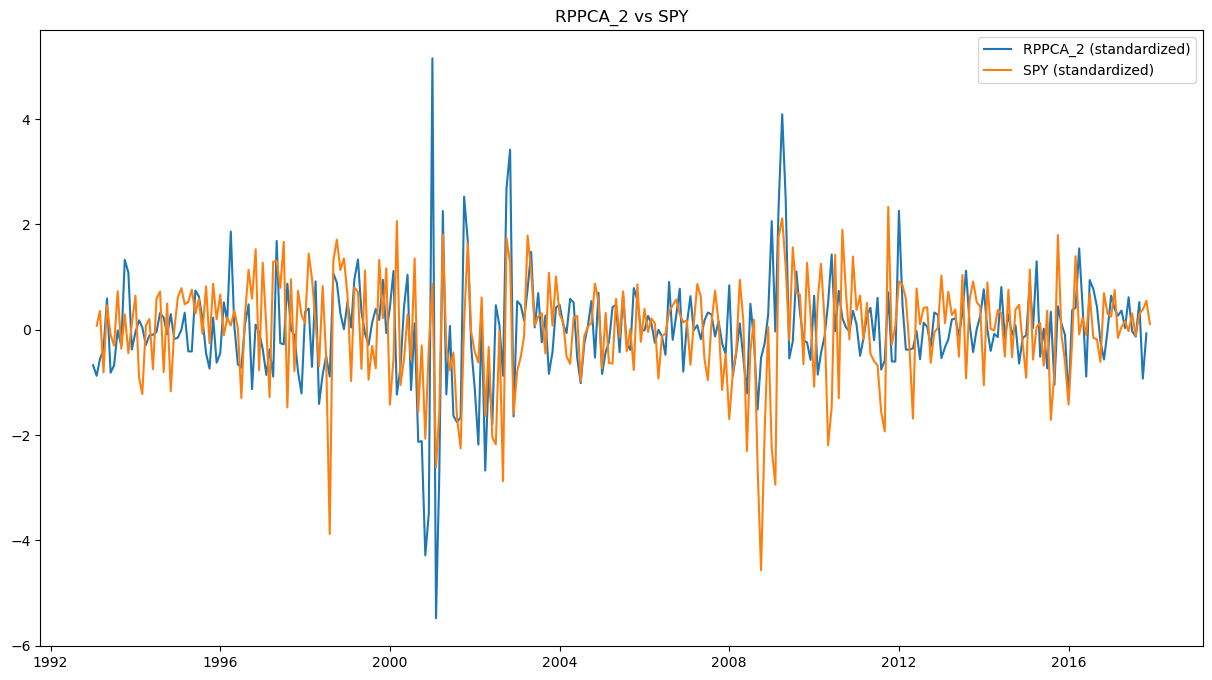

In [21]:
plt.figure(figsize=(15,8))

h_df = all_data.copy()
rppca2_std = (h_df['RPPCA_2'] - h_df['RPPCA_2'].mean()) / h_df['RPPCA_2'].std()
spy_data = import_spy_data()
spy_returns = np.log(spy_data['SPY']).diff()

plt.plot(h_df.index.to_timestamp(), rppca2_std, label='RPPCA_2 (standardized)')
plt.plot(spy_returns.index.to_timestamp(), (spy_returns - spy_returns.mean()) / spy_returns.std(), label='SPY (standardized)')

plt.legend()
plt.title("RPPCA_2 vs SPY")
plt.show()

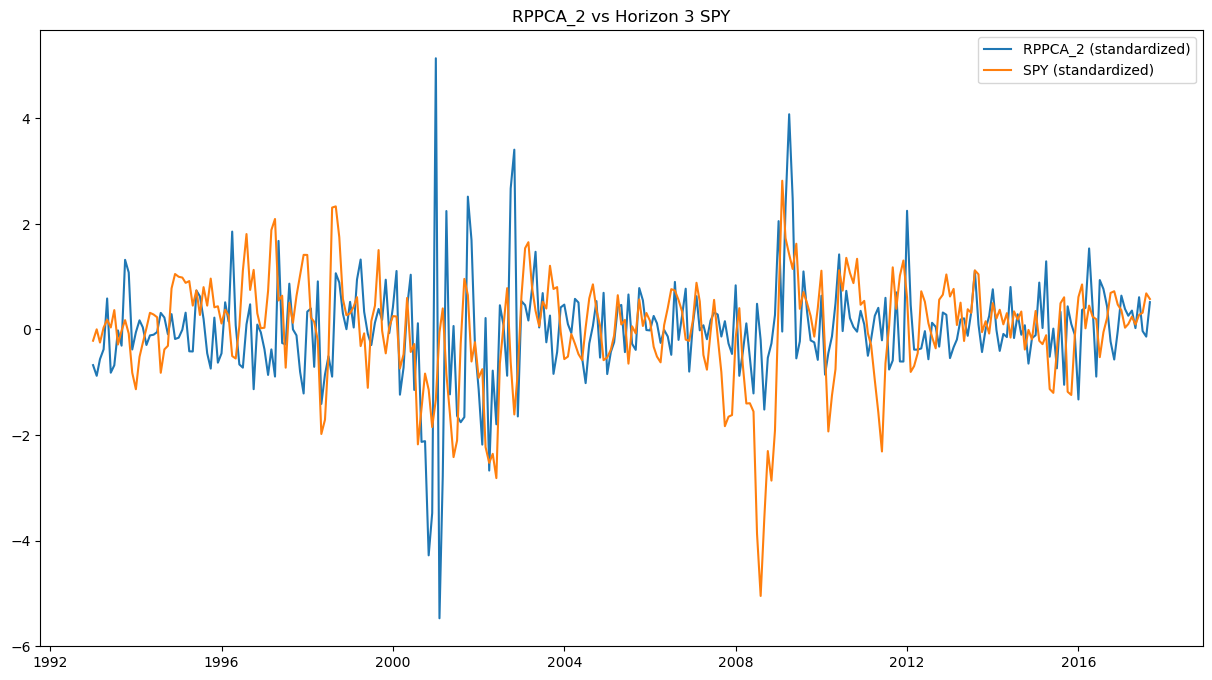

In [22]:
plt.figure(figsize=(15,8))

h_df = create_lagged_df(all_data, 3)
rppca2_std = (h_df['RPPCA_2'] - h_df['RPPCA_2'].mean()) / h_df['RPPCA_2'].std()
spy_returns = h_df['SPY_new']

plt.plot(h_df.index.to_timestamp(), rppca2_std, label='RPPCA_2 (standardized)')
plt.plot(h_df.index.to_timestamp(), (spy_returns - spy_returns.mean()) / spy_returns.std(), label='SPY (standardized)')

plt.legend()
plt.title("RPPCA_2 vs Horizon 3 SPY")
plt.show()

/var/folders/ml/wy9kw5gn3sn_qy_jzlwf72tc0000gn/T/ipykernel_27619/3471497023.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = h_df.groupby('bin')['SPY_new'].mean()


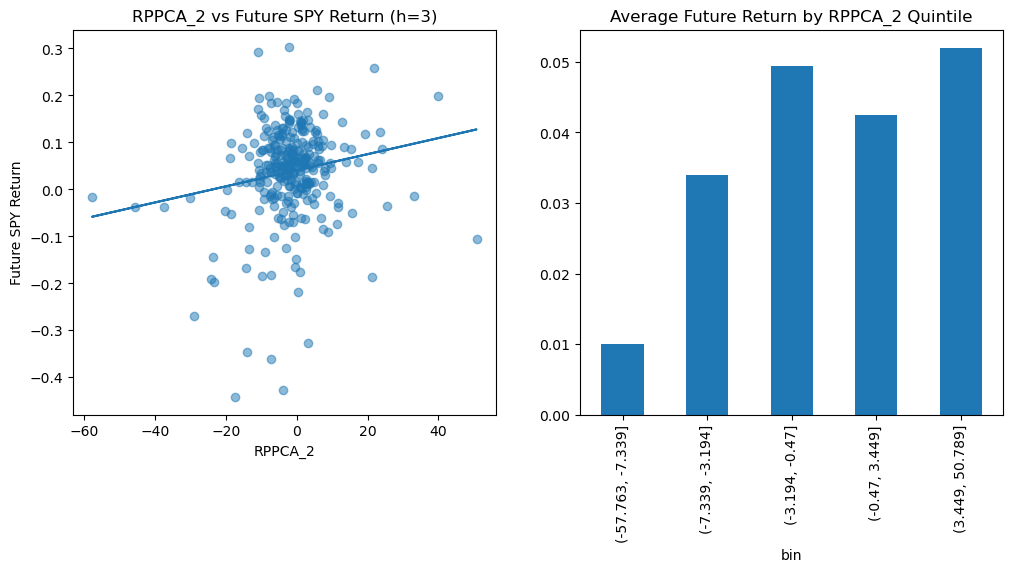

In [66]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

x = h_df['RPPCA_2']
y = h_df['SPY_new']
coef = np.polyfit(x, y, 1)
ax[0].plot(x, coef[0]*x + coef[1])
ax[0].scatter(h_df['RPPCA_2'], h_df['SPY_new'], alpha=0.5)
ax[0].set_title("RPPCA_2 vs Future SPY Return (h=3)")
ax[0].set_xlabel("RPPCA_2")
ax[0].set_ylabel("Future SPY Return")

h_df['bin'] = pd.qcut(h_df['RPPCA_2'], 5)
grouped = h_df.groupby('bin')['SPY_new'].mean()
grouped.plot(kind='bar', ax=ax[1])
ax[1].set_title("Average Future Return by RPPCA_2 Quintile")
plt.show()

These plots shows that there is an overall positive correlation between RPPCA 2 and future SPY (at a horizon of 3).

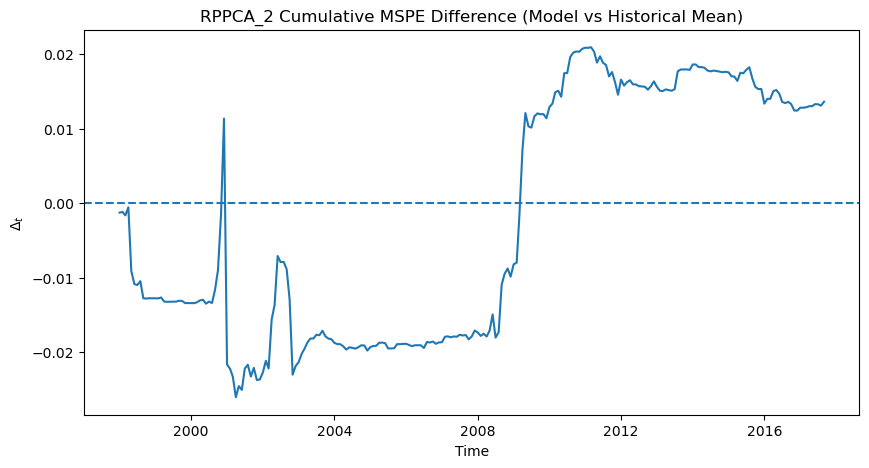

In [24]:
df = ml_output[3]['RPPCA_2'].copy()

err_model = df['Actual SPY Return'] - df['Predicted SPY Return']
err_hist = df['Actual SPY Return'] - df['Historical Mean Prediction']

cum_diff = np.cumsum(err_hist**2 - err_model**2)

plt.figure(figsize=(10,5))
plt.plot(df.index.to_timestamp(), cum_diff)
plt.xlabel("Time")
plt.ylabel(r"$\Delta_t$")
plt.title("RPPCA_2 Cumulative MSPE Difference (Model vs Historical Mean)")
plt.axhline(0, linestyle='--')
plt.show()

$\Delta_t = e_{\text{hist}}^2 - e_{\text{model}}^2$

Over time, the $\Delta_t$ seems to move upwards to more positive values, suggesting that post-2008 the RPPCA_2 model begins beating the historical mean. Perhaps this is indicative of a regime-dependent strategy.

While statistical significance is limited, the second RP-PCA factor exhibits consistent, albeit weak, predictive power for future SPY returns, particularly at medium horizons (3–5 months).

The relationship is economically interpretable: higher values of the factor are associated with higher subsequent returns, as evidenced by both linear fits and monotonic quintile sorting.

Out-of-sample performance is modest but positive, with small improvements over a historical mean benchmark. Importantly, these gains are not uniform over time—most of the predictive value emerges in the post-2008 period, suggesting that the factor may be capturing regime-dependent macroeconomic conditions.

[*********************100%***********************]  1 of 1 completed


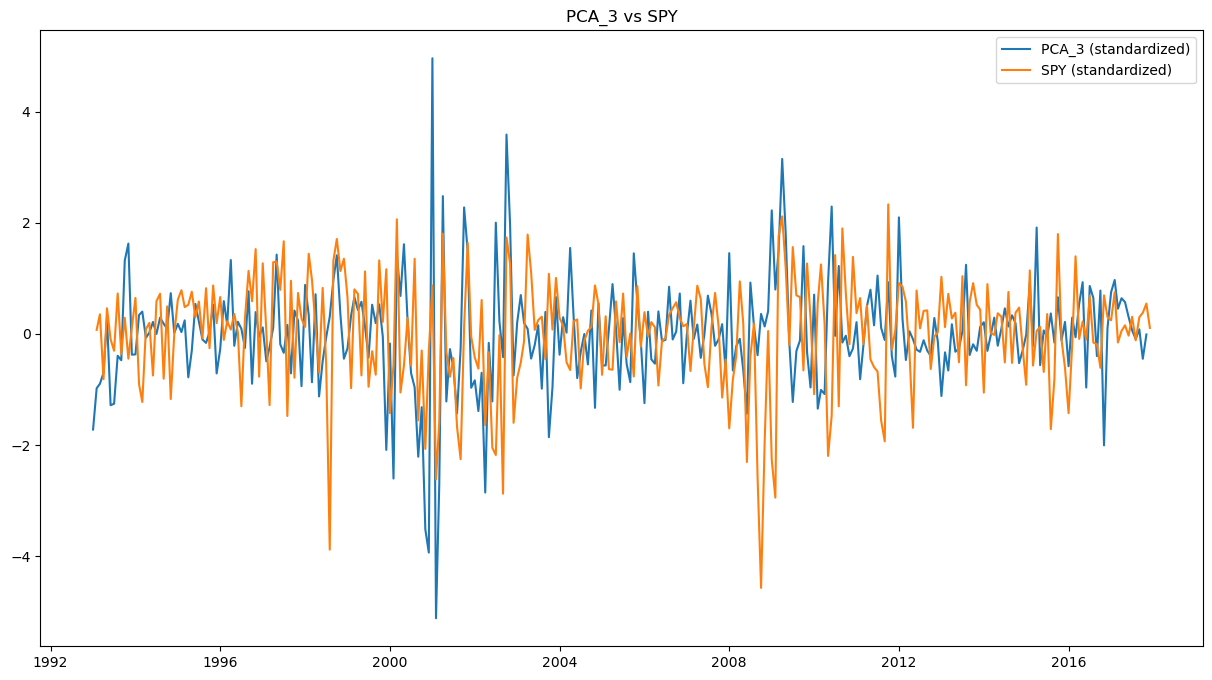

In [25]:
plt.figure(figsize=(15,8))

h_df = all_data.copy()
rppca2_std = (h_df['PCA_3'] - h_df['PCA_3'].mean()) / h_df['PCA_3'].std()
spy_data = import_spy_data()
spy_returns = np.log(spy_data['SPY']).diff()

plt.plot(h_df.index.to_timestamp(), rppca2_std, label='PCA_3 (standardized)')
plt.plot(spy_returns.index.to_timestamp(), (spy_returns - spy_returns.mean()) / spy_returns.std(), label='SPY (standardized)')

plt.legend()
plt.title("PCA_3 vs SPY")
plt.show()

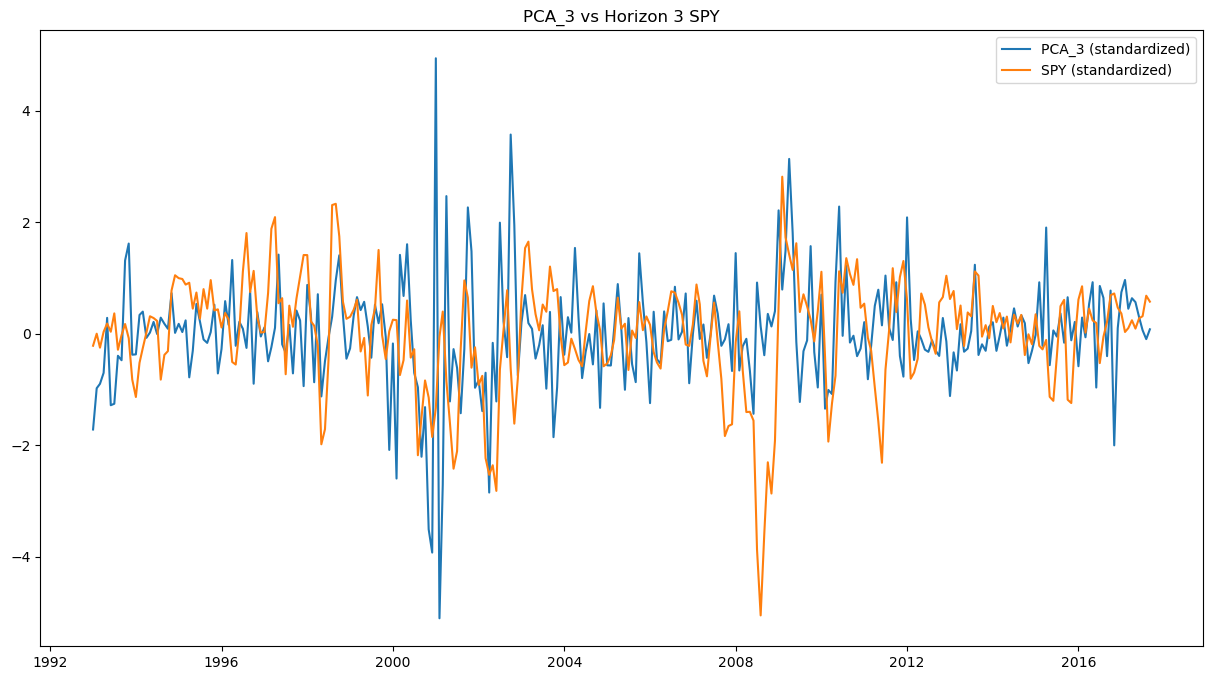

In [26]:
plt.figure(figsize=(15,8))

h_df = create_lagged_df(all_data, 3)
rppca2_std = (h_df['PCA_3'] - h_df['PCA_3'].mean()) / h_df['PCA_3'].std()
spy_returns = h_df['SPY_new']

plt.plot(h_df.index.to_timestamp(), rppca2_std, label='PCA_3 (standardized)')
plt.plot(h_df.index.to_timestamp(), (spy_returns - spy_returns.mean()) / spy_returns.std(), label='SPY (standardized)')

plt.legend()
plt.title("PCA_3 vs Horizon 3 SPY")
plt.show()

/var/folders/ml/wy9kw5gn3sn_qy_jzlwf72tc0000gn/T/ipykernel_27619/3195266665.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = h_df.groupby('bin')['SPY_new'].mean()


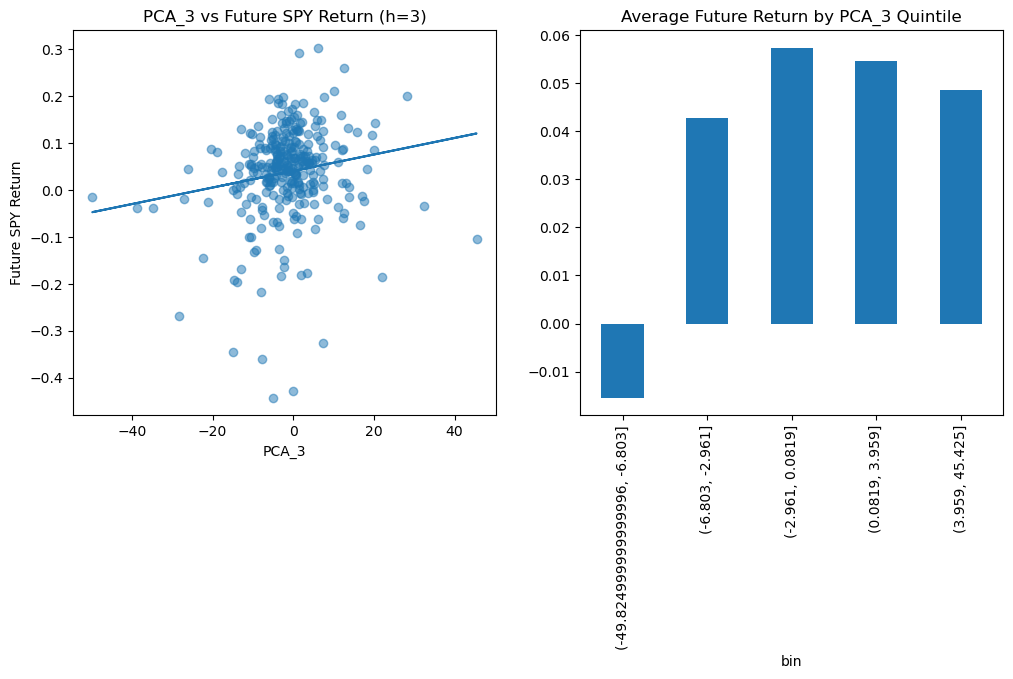

In [67]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

x = h_df['PCA_3']
y = h_df['SPY_new']
coef = np.polyfit(x, y, 1)
ax[0].plot(x, coef[0]*x + coef[1])
ax[0].scatter(h_df['PCA_3'], h_df['SPY_new'], alpha=0.5)
ax[0].set_title("PCA_3 vs Future SPY Return (h=3)")
ax[0].set_xlabel("PCA_3")
ax[0].set_ylabel("Future SPY Return")

h_df['bin'] = pd.qcut(h_df['PCA_3'], 5)
grouped = h_df.groupby('bin')['SPY_new'].mean()
grouped.plot(kind='bar', ax=ax[1])
ax[1].set_title("Average Future Return by PCA_3 Quintile")
plt.show()

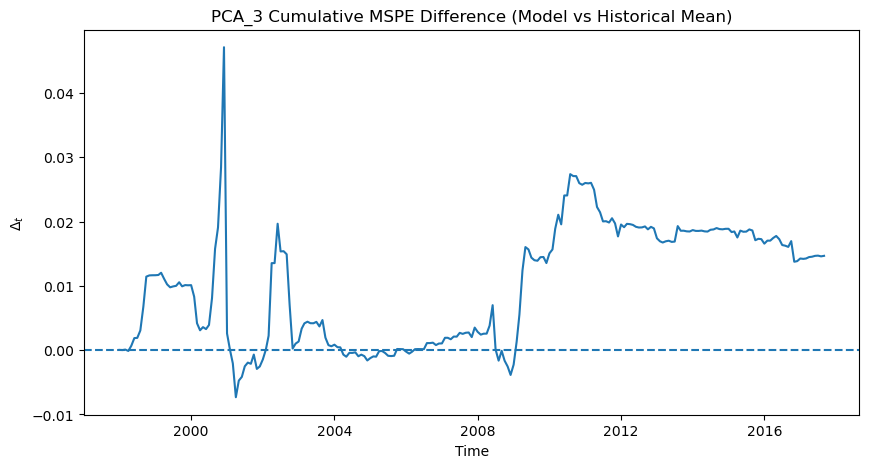

In [28]:
df = ml_output[3]['PCA_3'].copy()

err_model = df['Actual SPY Return'] - df['Predicted SPY Return']
err_hist = df['Actual SPY Return'] - df['Historical Mean Prediction']

cum_diff = np.cumsum(err_hist**2 - err_model**2)

plt.figure(figsize=(10,5))
plt.plot(df.index.to_timestamp(), cum_diff)
plt.xlabel("Time")
plt.ylabel(r"$\Delta_t$")
plt.title("PCA_3 Cumulative MSPE Difference (Model vs Historical Mean)")
plt.axhline(0, linestyle='--')
plt.show()

We see a positive relationship exhibited by PCA 3 as well. The graph above is over the positive line for most of the period in consideration, suggesting that PCA 3 performs better than the historical mean largely, only rarely dipping below it.

The PCA 3 $R^2$ values are slightly better than RP-PCA 2 $R^2$ values. However, they are still pretty small, and so we can only say the same thing - there is a weak signal present that is not statistically-robust, but is being captured by PCA 3. This is especially evidenced by the plot above which shows that PCA 3's prediction is mostly better than the historical mean.

I notice in the case of PCA 3 as well that performance seems to boost tremendously right after 2000 and 2008, which could again suggest some kind of regime-dependent performance and strategy.

[*********************100%***********************]  1 of 1 completed


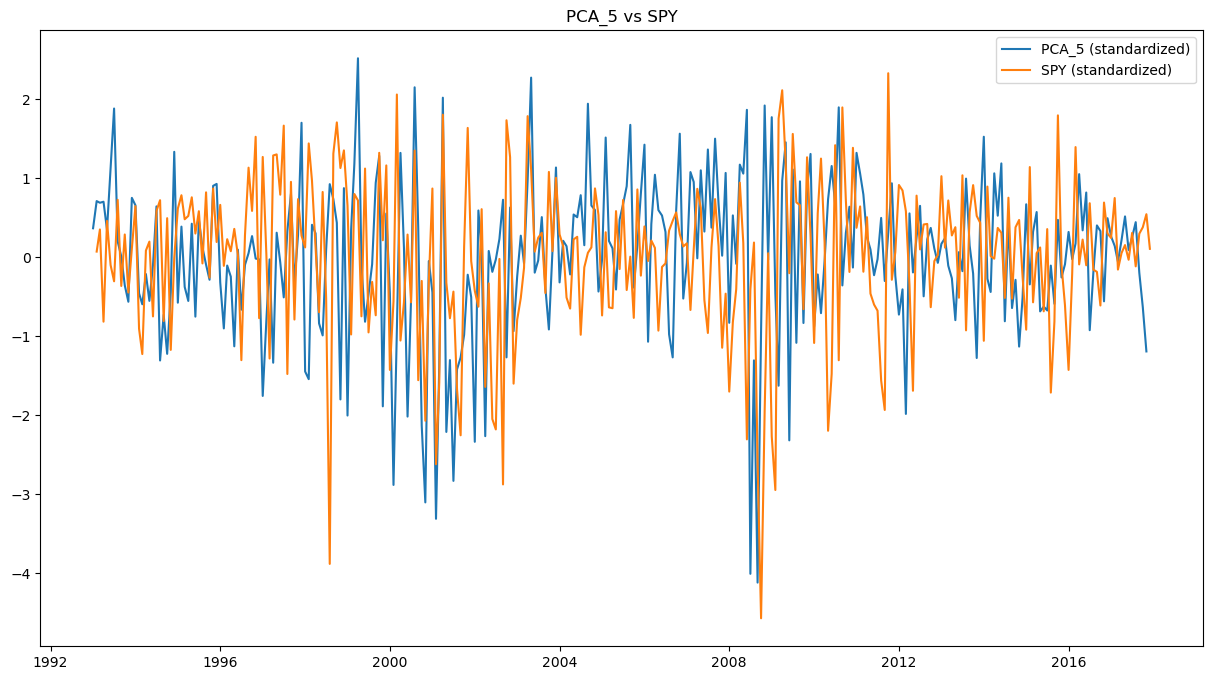

In [29]:
plt.figure(figsize=(15,8))

h_df = all_data.copy()
rppca2_std = (h_df['PCA_5'] - h_df['PCA_5'].mean()) / h_df['PCA_5'].std()
spy_data = import_spy_data()
spy_returns = np.log(spy_data['SPY']).diff()

plt.plot(h_df.index.to_timestamp(), rppca2_std, label='PCA_5 (standardized)')
plt.plot(spy_returns.index.to_timestamp(), (spy_returns - spy_returns.mean()) / spy_returns.std(), label='SPY (standardized)')

plt.legend()
plt.title("PCA_5 vs SPY")
plt.show()

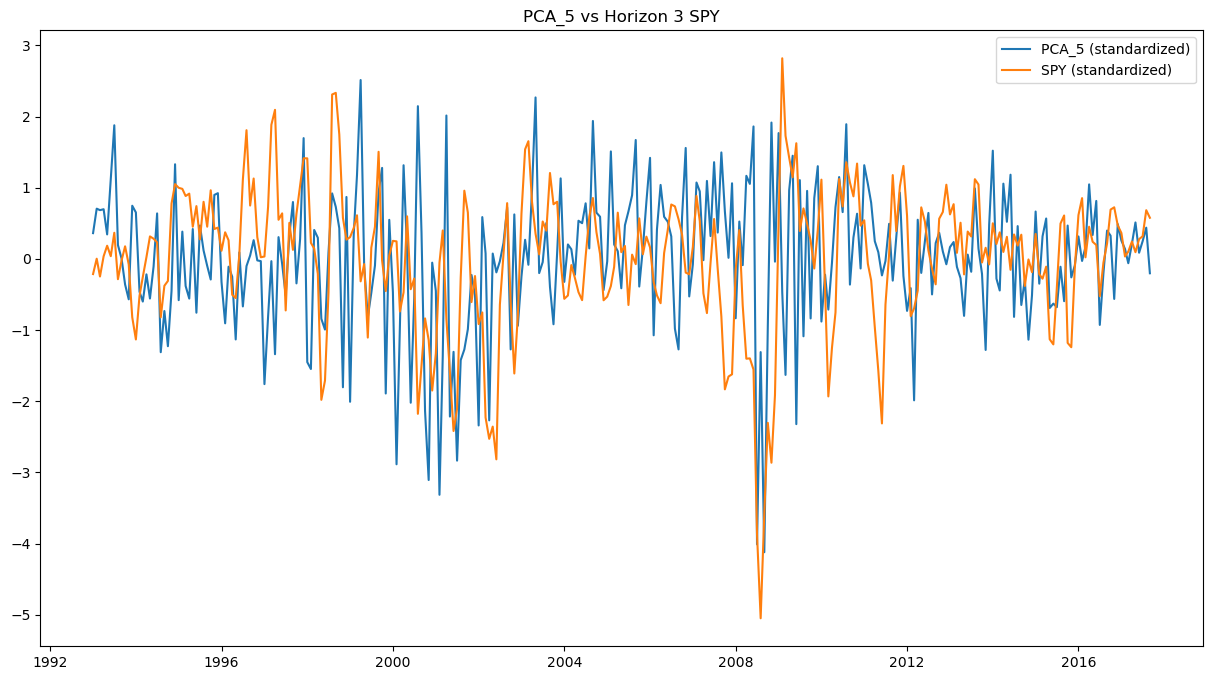

In [30]:
plt.figure(figsize=(15,8))

h_df = create_lagged_df(all_data, 3)
rppca2_std = (h_df['PCA_5'] - h_df['PCA_5'].mean()) / h_df['PCA_5'].std()
spy_returns = h_df['SPY_new']

plt.plot(h_df.index.to_timestamp(), rppca2_std, label='PCA_5 (standardized)')
plt.plot(h_df.index.to_timestamp(), (spy_returns - spy_returns.mean()) / spy_returns.std(), label='SPY (standardized)')

plt.legend()
plt.title("PCA_5 vs Horizon 3 SPY")
plt.show()

/var/folders/ml/wy9kw5gn3sn_qy_jzlwf72tc0000gn/T/ipykernel_27619/834547466.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = h_df.groupby('bin')['SPY_new'].mean()


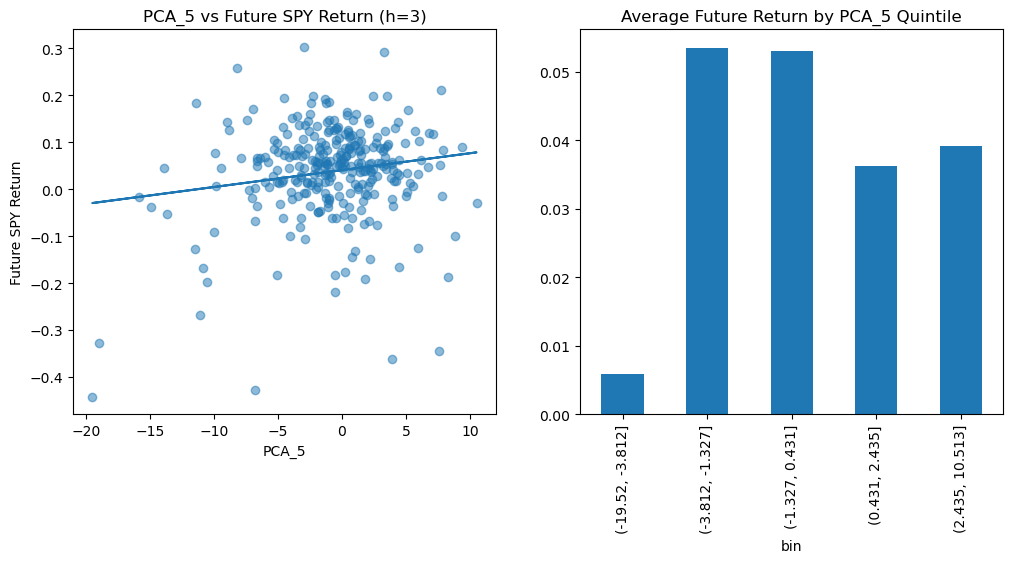

In [68]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

x = h_df['PCA_5']
y = h_df['SPY_new']
coef = np.polyfit(x, y, 1)
ax[0].plot(x, coef[0]*x + coef[1])
ax[0].scatter(h_df['PCA_5'], h_df['SPY_new'], alpha=0.5)
ax[0].set_title("PCA_5 vs Future SPY Return (h=3)")
ax[0].set_xlabel("PCA_5")
ax[0].set_ylabel("Future SPY Return")

h_df['bin'] = pd.qcut(h_df['PCA_5'], 5)
grouped = h_df.groupby('bin')['SPY_new'].mean()
grouped.plot(kind='bar', ax=ax[1])
ax[1].set_title("Average Future Return by PCA_5 Quintile")
plt.show()

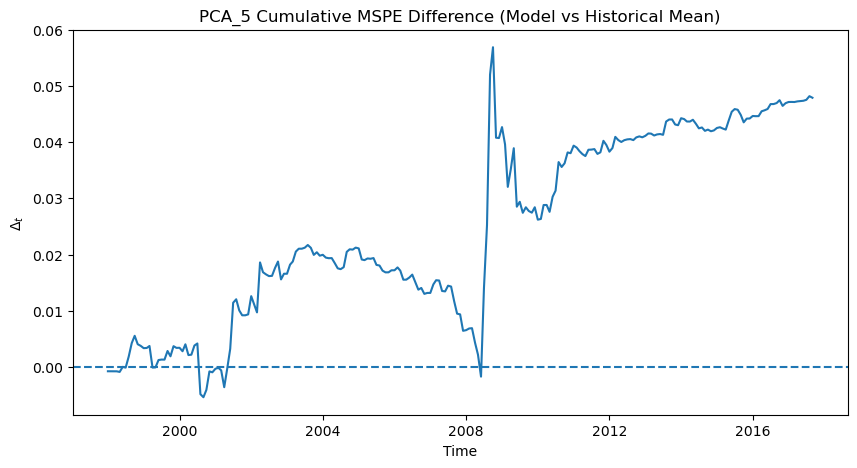

In [32]:
df = ml_output[3]['PCA_5'].copy()

err_model = df['Actual SPY Return'] - df['Predicted SPY Return']
err_hist = df['Actual SPY Return'] - df['Historical Mean Prediction']

cum_diff = np.cumsum(err_hist**2 - err_model**2)

plt.figure(figsize=(10,5))
plt.plot(df.index.to_timestamp(), cum_diff)
plt.xlabel("Time")
plt.ylabel(r"$\Delta_t$")
plt.title("PCA_5 Cumulative MSPE Difference (Model vs Historical Mean)")
plt.axhline(0, linestyle='--')
plt.show()

## 3. Combinations of Factors

### In-Sample RP-PCA 2 and PCA 3 (Horizon 3)

In [33]:
factor = "PCA_3_RPPCA_2_h_3"
h3_df = create_lagged_df(all_data, 3)
y = h3_df['SPY_new']
X = sm.add_constant(h3_df[['RPPCA_2', 'PCA_3']])

model = sm.OLS(y, X)
result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})

# in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
# in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
# in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                SPY_new   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     2.247
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.108
Time:                        07:37:08   Log-Likelihood:                 356.69
No. Observations:                 297   AIC:                            -707.4
Df Residuals:                     294   BIC:                            -696.3
Df Model:                           2                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0249      0.006      3.850      0.000       0.012       0.038
RPPCA_2        0.0010      0.001      1.118      0.264      -0.001       0.003
PCA_3          0.0003      0.001      0.347      0.729      -0.001       0.002
==============================================================================
Omnibus:                       70.245   Durbin-Watson:                   0.653
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              188.954
Skew:                          -1.080   Prob(JB):                     9.32e-42
Kurtosis:                       6.256   Cond. No.                         13.7
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

The statistical significance of both vanishes. 

oiwefoiunwefwef

### In-Sample RP-PCA 2 - PCA 3 (Horizon 3)

In [34]:
factor = "RPPCA_2_resid_PCA_3_h_3"

h3_df = create_lagged_df(all_data, 3)
y = h3_df['SPY_new']
X = sm.add_constant(h3_df['RPPCA_2'] - h3_df['PCA_3'])

model = sm.OLS(y, X)
result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})

# in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
# in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
# in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                SPY_new   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.5697
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.451
Time:                        07:37:08   Log-Likelihood:                 352.39
No. Observations:                 297   AIC:                            -700.8
Df Residuals:                     295   BIC:                            -693.4
Df Model:                           1                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0229      0.007      3.423      0.001       0.010       0.036
0              0.0006      0.001      0.755      0.450      -0.001       0.002
==============================================================================
Omnibus:                       67.368   Durbin-Watson:                   0.574
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              173.374
Skew:                          -1.053   Prob(JB):                     2.25e-38
Kurtosis:                       6.094   Cond. No.                         5.94
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

Again, no statistical significance and very small coefficient. Perhaps whatever latent signal it is that both PCA and RP-PCA are capturing is destroyed when we remove the PCA 3 component from RP-PCA 2.

### In-Sample RP-PCA 2 - PCA 3 (Horizon 1)

In [35]:
factor = "RPPCA_2_resid_PCA_3_h_1"

h1_df = create_lagged_df(all_data, 1)
y = h1_df['SPY_new']
X = sm.add_constant(h1_df['RPPCA_2'] - h1_df['PCA_3'])

model = sm.OLS(y, X)
result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})

# in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
# in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
# in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                SPY_new   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.187
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.277
Time:                        07:37:08   Log-Likelihood:                 530.96
No. Observations:                 299   AIC:                            -1058.
Df Residuals:                     297   BIC:                            -1051.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0078      0.002      3.261      0.001       0.003       0.012
0              0.0005      0.001      1.090      0.276      -0.000       0.002
==============================================================================
Omnibus:                       40.958   Durbin-Watson:                   1.913
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               67.286
Skew:                          -0.804   Prob(JB):                     2.45e-15
Kurtosis:                       4.678   Cond. No.                         5.94
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

Similar result as previous run. Small coefficient that is not statistically-significant

### Out-of-Sample RP-PCA 2 + PCA 3

In [36]:
factor = "RPPCA2_PCA3"
horizons = [1,3,5]
ml_output = defaultdict(dict)

for h in horizons:
    
    h_df = create_lagged_df(all_data, h)
    date_ranges = create_train_predict_calendar(df=h_df, window_type='expanding', window_size=60)
    
    X = sm.add_constant(h_df[['RPPCA_2', 'PCA_3']])
    y = h_df['SPY_new']
    results_df = pd.DataFrame(index=[d[2] for d in date_ranges])
    
    for n, dates in enumerate(date_ranges):
        #create X and y
        start_train, end_train, pred_date = dates[0], dates[1], dates[2]
        fit_X = X.loc[start_train:end_train]
        fit_y = y.loc[start_train:end_train]
        pred_X = X.loc[[pred_date]]
        
        # fit model
        model = sm.OLS(fit_y, fit_X)
        result = model.fit(cov_type='HAC', cov_kwds={'maxlags': h})

        # obtain predictions
        prediction = result.predict(pred_X)
        results_df.loc[pred_date, 'Predicted SPY Return'] = prediction.iloc[0]
        results_df.loc[pred_date, 'Historical Mean Prediction'] = fit_y.mean()
        # results_df.loc[pred_date, 'Factor Coefficient'] = result.params.loc[factor]

    # feed to sizer function and obtain portfolio leverage
    results_df['Actual SPY Return'] = y.loc[results_df.index]
    
    # store dataframe in final output dictionary
    ml_output[h][factor] = results_df.dropna()

    print(f"\nFinished running {h} {factor}\n")


Finished running 1 RPPCA2_PCA3


Finished running 3 RPPCA2_PCA3


Finished running 5 RPPCA2_PCA3



In [37]:
metrics_output = defaultdict(dict)

for h in horizons:
    results_df = ml_output[h][factor]
    metrics_output[h][factor] = compute_oos_metrics(results_df)

r2_table = pd.DataFrame(index=rp_pca_cols, columns=horizons, dtype=float)
cw_p_table = pd.DataFrame(index=rp_pca_cols, columns=horizons, dtype=float)
success_table = pd.DataFrame(index=rp_pca_cols, columns=horizons, dtype=float)

for h in horizons:
    r2_table.loc[factor, h] = metrics_output[h][factor]['R2_OS']
    cw_p_table.loc[factor, h] = metrics_output[h][factor]['CW_pvalue_one_sided']
    success_table.loc[factor, h] = metrics_output[h][factor]['Success_Ratio']

print("OOS R^2")
r2_table

OOS R^2


,1,3,5
RPPCA_1,NaN,NaN,NaN
RPPCA_2,NaN,NaN,NaN
RPPCA_3,NaN,NaN,NaN
RPPCA_4,NaN,NaN,NaN
RPPCA_5,NaN,NaN,NaN
RPPCA2_PCA3,-0.032287,-0.012992,-0.008579


Negative $R^2$ values for this combination

### In-Sample RP-PCA 2 + PCA 5 (Horizon 3)

In [38]:
factor = "RPPCA_2_PCA_5"
h5_df = create_lagged_df(all_data, 3)
y = h5_df['SPY_new']
X = sm.add_constant(h5_df[['RPPCA_2', 'PCA_5']])

model = sm.OLS(y, X)
result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})

# in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
# in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
# in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                SPY_new   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     3.410
Date:                Wed, 29 Apr 2026   Prob (F-statistic):             0.0343
Time:                        07:37:08   Log-Likelihood:                 361.28
No. Observations:                 297   AIC:                            -716.6
Df Residuals:                     294   BIC:                            -705.5
Df Model:                           2                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0269      0.006      4.548      0.000       0.015       0.038
RPPCA_2        0.0010      0.001      1.607      0.108      -0.000       0.002
PCA_5          0.0029      0.002      1.807      0.071      -0.000       0.006
==============================================================================
Omnibus:                       53.140   Durbin-Watson:                   0.711
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              121.964
Skew:                          -0.874   Prob(JB):                     3.28e-27
Kurtosis:                       5.608   Cond. No.                         10.7
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

PCA 5 is borderline statistically significant, but I wouldn't consider it

### In-Sample All PCA Factors (Horizon 3)

In [39]:
factor = "All_PCA"
h3_df = create_lagged_df(all_data, 3)
result = sm.OLS(h3_df['SPY_new'], h3_df[pca_cols]).fit()

# in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
# in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
# in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                SPY_new   R-squared (uncentered):                   0.037
Model:                            OLS   Adj. R-squared (uncentered):              0.021
Method:                 Least Squares   F-statistic:                              2.248
Date:                Wed, 29 Apr 2026   Prob (F-statistic):                      0.0497
Time:                        07:37:08   Log-Likelihood:                          344.31
No. Observations:                 297   AIC:                                     -678.6
Df Residuals:                     292   BIC:                                     -660.2
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
PCA_1         -0.0002      0.000     -1.711      0.088      -0.000    2.68e-05
PCA_2         -0.0003      0.000     -0.585      0.559      -0.001       0.001
PCA_3          0.0006      0.000      1.347      0.179      -0.000       0.002
PCA_4         -0.0003      0.000     -0.605      0.545      -0.001       0.001
PCA_5          0.0020      0.001      2.025      0.044    5.56e-05       0.004
==============================================================================
Omnibus:                       53.530   Durbin-Watson:                   0.674
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              125.343
Skew:                          -0.872   Prob(JB):                     6.06e-28
Kurtosis:                       5.662   Cond. No.                         9.85
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### In-Sample All RP-PCA Factors (Horizon 3)

In [40]:
factor = "All_RPPCA"
h3_df = create_lagged_df(all_data, 3)
result = sm.OLS(h3_df['SPY_new'], h3_df[rp_pca_cols]).fit()

# in_sample_results.loc["t-stat", f"{factor}"] = result.tvalues[factor]
# in_sample_results.loc["p-value", f"{factor}"] = result.pvalues[factor]
# in_sample_results.loc["R-Squared", f"{factor}"] = result.rsquared

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                SPY_new   R-squared (uncentered):                   0.027
Model:                            OLS   Adj. R-squared (uncentered):              0.010
Method:                 Least Squares   F-statistic:                              1.616
Date:                Wed, 29 Apr 2026   Prob (F-statistic):                       0.156
Time:                        07:37:08   Log-Likelihood:                          342.76
No. Observations:                 297   AIC:                                     -675.5
Df Residuals:                     292   BIC:                                     -657.0
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
RPPCA_1       -0.0001      0.000     -0.888      0.376      -0.000       0.000
RPPCA_2        0.0009      0.001      1.548      0.123      -0.000       0.002
RPPCA_3        0.0005      0.000      1.064      0.288      -0.000       0.001
RPPCA_4       -0.0006      0.000     -1.195      0.233      -0.002       0.000
RPPCA_5        0.0008      0.001      0.849      0.396      -0.001       0.003
==============================================================================
Omnibus:                       60.387   Durbin-Watson:                   0.658
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              155.455
Skew:                          -0.944   Prob(JB):                     1.75e-34
Kurtosis:                       5.999   Cond. No.                         10.3
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [41]:
factor = "PCA_3_PCA_5_h_3"
h3_df = create_lagged_df(all_data, 3)
y = h3_df['SPY_new']
X = sm.add_constant(h3_df[['PCA_5', 'PCA_3']])

model = sm.OLS(y, X)
result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                SPY_new   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     3.850
Date:                Wed, 29 Apr 2026   Prob (F-statistic):             0.0224
Time:                        07:37:08   Log-Likelihood:                 361.26
No. Observations:                 297   AIC:                            -716.5
Df Residuals:                     294   BIC:                            -705.4
Df Model:                           2                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0268      0.006      4.422      0.000       0.015       0.039
PCA_5          0.0031      0.002      1.908      0.056   -8.59e-05       0.006
PCA_3          0.0010      0.001      1.638      0.101      -0.000       0.002
==============================================================================
Omnibus:                       55.541   Durbin-Watson:                   0.682
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              126.023
Skew:                          -0.916   Prob(JB):                     4.31e-28
Kurtosis:                       5.613   Cond. No.                         9.87
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

In [42]:
sm.OLS(all_data['PCA_3'], all_data['PCA_5']).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  PCA_3   R-squared (uncentered):                   0.026
Model:                            OLS   Adj. R-squared (uncentered):              0.023
Method:                 Least Squares   F-statistic:                              7.912
Date:                Wed, 29 Apr 2026   Prob (F-statistic):                     0.00524
Time:                        07:37:08   Log-Likelihood:                         -1095.0
No. Observations:                 299   AIC:                                      2192.
Df Residuals:                     298   BIC:                                      2196.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
PCA_5          0.3336      0.119      2.813      0.005       0.100       0.567
==============================================================================
Omnibus:                       39.313   Durbin-Watson:                   1.956
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              276.780
Skew:                           0.098   Prob(JB):                     7.91e-61
Kurtosis:                       7.709   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Conclusion

Even though these factors exhibit some predictive power and statistical significance individually, they lose that power when paired with other factors. Even the RP-PCA/PCA factors together aren't able to produce as much significance as the individual factors.

To understand why, let's turn our attention towards the economic interpretation of these factors.

## 4. Economic Meaning of Factors

In [43]:
all_data[["RPPCA_2", "PCA_3", "PCA_5"]].corr()

,RPPCA_2,PCA_3,PCA_5
RPPCA_2,1.000000,0.821116,0.232537
PCA_3,0.821116,1.000000,0.135326
PCA_5,0.232537,0.135326,1.000000


At the very outset, we see something very interesting - there is more than 80% correlation between RPPCA_2 and PCA_3. This suggests that there is some latent macroeconomic factor that both RP-PCA 2 and PCA 3 are capturing and representing. It also explains why including both in the same regression reduced our significance levels: there is multicollinearity because these are essentially the same factor.



### Correlation with H = 1 SPY

In [44]:
all_data.corr()['SPY']

RPPCA_1       -0.076014
RPPCA_2        0.101674
RPPCA_3        0.018189
RPPCA_4       -0.000172
RPPCA_5        0.054056
PCA_1         -0.077169
PCA_2         -0.003225
PCA_3          0.060635
PCA_4          0.027372
PCA_5          0.057126
SMV_RPPCA_1    0.076014
SMV_RPPCA_2   -0.101674
SMV_RPPCA_3    0.054056
SMV_RPPCA_4   -0.018189
SMV_RPPCA_5    0.027757
SMV_PCA_1     -0.077169
SMV_PCA_2     -0.060635
SMV_PCA_3     -0.027372
SMV_PCA_4      0.036758
SMV_PCA_5      0.057126
SPY            1.000000
Name: SPY, dtype: float64

### Contemporaneous Correlation with SPY

In [45]:
fresh_spy = import_spy_data()
fresh_factors = import_factors_data()
fresh_data = fresh_factors.join(fresh_spy, how='inner')
fresh_data['SPY'] = np.log(fresh_data['SPY']).diff()
fresh_data = fresh_data.dropna()
fresh_data.corr()

[*********************100%***********************]  1 of 1 completed


,RPPCA_1,RPPCA_2,RPPCA_3,RPPCA_4,RPPCA_5,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,SMV_RPPCA_1,SMV_RPPCA_2,SMV_RPPCA_3,SMV_RPPCA_4,SMV_RPPCA_5,SMV_PCA_1,SMV_PCA_2,SMV_PCA_3,SMV_PCA_4,SMV_PCA_5,SPY
RPPCA_1,1.000000,-0.506810,0.057287,-0.105746,-0.072060,0.999931,-0.118667,-0.151589,-0.178326,-0.132608,-1.000000,0.506810,-0.072060,-0.057287,0.067017,0.999931,0.151589,0.178326,-0.171918,-0.132608,-0.935184
RPPCA_2,-0.506810,1.000000,-0.151365,0.045624,-0.475492,-0.516695,0.301182,0.821818,0.460640,0.233611,0.506810,-1.000000,-0.475492,0.151365,-0.203141,-0.516695,-0.821818,-0.460640,0.007033,0.233611,0.371808
RPPCA_3,0.057287,-0.151365,1.000000,0.226455,-0.086181,0.057693,-0.987977,-0.045552,0.220751,0.042787,-0.057287,0.151365,-0.086181,-1.000000,0.009662,0.057693,0.045552,-0.220751,0.117917,0.042787,-0.001647
RPPCA_4,-0.105746,0.045624,0.226455,1.000000,-0.081688,-0.106275,-0.215666,-0.395654,0.884088,-0.039040,0.105746,-0.045624,-0.081688,-0.226455,-0.020539,-0.106275,0.395654,-0.884088,0.067431,-0.039040,-0.157136
RPPCA_5,-0.072060,-0.475492,-0.086181,-0.081688,1.000000,-0.066460,-0.002249,-0.625458,-0.420561,0.344074,0.072060,0.475492,1.000000,0.086181,-0.095632,-0.066460,0.625458,0.420561,-0.359160,0.344074,0.172707
PCA_1,0.999931,-0.516695,0.057693,-0.106275,-0.066460,1.000000,-0.120683,-0.161133,-0.183720,-0.135793,-0.999931,0.516695,-0.066460,-0.057693,0.069525,1.000000,0.161133,0.183720,-0.170063,-0.135793,-0.933772
PCA_2,-0.118667,0.301182,-0.987977,-0.215666,-0.002249,-0.120683,1.000000,0.179376,-0.141793,-0.008412,0.118667,-0.301182,-0.002249,0.987977,-0.040497,-0.120683,-0.179376,0.141793,-0.112715,-0.008412,0.044521
PCA_3,-0.151589,0.821818,-0.045552,-0.395654,-0.625458,-0.161133,0.179376,1.000000,0.078921,0.138160,0.151589,-0.821818,-0.625458,0.045552,-0.146165,-0.161133,-1.000000,-0.078921,0.033514,0.138160,0.156782
PCA_4,-0.178326,0.460640,0.220751,0.884088,-0.420561,-0.183720,-0.141793,0.078921,1.000000,0.016840,0.178326,-0.460640,-0.420561,-0.220751,-0.092101,-0.183720,-0.078921,-1.000000,0.096356,0.016840,-0.104730
PCA_5,-0.132608,0.233611,0.042787,-0.039040,0.344074,-0.135793,-0.008412,0.138160,0.016840,1.000000,0.132608,-0.233611,0.344074,-0.042787,-0.165657,-0.135793,-0.138160,-0.016840,-0.013008,1.000000,0.119302


### Relation with Sector ETFs

In [46]:
etf_list = ['XLK', 'XLF', 'XLV', 'XLY', 'XLP', 'XLE', 'XLI', 'XLB', 'XLU'] #Sector ETFs as features
start_date, end_date = '1963-11-01', '2017-12-31'

etf_data = yf.download(etf_list, start=start_date, end=end_date, auto_adjust=True)
etf_data = etf_data['Close']
etf_data.index.name = 'Date'
etf_data = etf_data.resample("M").last()
etf_data = etf_data.astype(float)
etf_data = np.log(etf_data).diff().dropna()
etf_data.index = etf_data.index.to_period('M')
etf_data = etf_data.dropna()
combined_data = etf_data.join(all_daa[rp_pca_cols + pca_cols], how='left').dropna()
# combined_data = combined_data.join(create_lagged_df(all_data, 3), how='left').dropna()
combined_data = combined_data.join(fresh_data['SPY'], how='left').dropna()
combined_data

[*********************100%***********************]  9 of 9 completed


,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,RPPCA_1,RPPCA_2,RPPCA_3,RPPCA_4,RPPCA_5,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,SPY
Date,,,,,,,,,,,,,,,,,,,,
1999-01,-0.037768,-0.067846,0.017185,-0.010874,0.147561,-0.013322,-0.025119,0.046957,0.050156,-51.366763,3.571839,20.797806,22.773905,-8.511402,-51.496470,-20.058452,-3.921563,23.755210,-9.949586,0.034619
1999-02,0.015425,-0.008633,0.015605,0.008963,-0.104442,-0.010551,-0.027943,0.001147,-0.006277,49.171071,-1.396201,-6.993693,-3.581421,-0.117306,49.187822,6.865955,1.691915,-3.048213,0.687865,-0.032594
1999-03,0.017829,0.132231,0.031896,0.020788,0.071680,-0.001186,-0.065165,0.026005,0.047501,-33.991288,7.903937,13.045493,3.605232,2.298211,-34.515539,-11.700198,4.802332,6.339655,4.475119,0.040631
1999-04,0.220842,0.138048,0.067823,0.140088,0.005960,-0.035493,0.092218,0.035091,0.025892,-39.829291,11.776143,-26.863695,-3.646026,8.656626,-40.460013,28.171636,2.598587,-3.096450,10.512727,0.037271
1999-05,-0.095425,-0.021819,-0.062200,-0.019802,0.003390,-0.010465,0.011677,-0.031192,-0.046318,12.351899,1.641249,-20.411680,-5.396565,-5.899154,12.506804,20.583774,4.005843,-3.623503,-1.299276,-0.023131
1999-06,0.056181,0.020208,0.042472,0.059543,0.091689,0.017505,0.040351,0.042976,0.062462,-42.179219,-2.609803,15.277034,3.133641,-7.363735,-41.841265,-15.533289,-0.215390,3.631034,-4.576901,0.053899
1999-07,-0.011484,0.018764,-0.063023,-0.037378,-0.011646,-0.037951,0.003055,-0.030273,-0.077422,29.408491,-4.802201,-5.257622,7.490299,-2.330772,29.748467,4.534324,-5.502645,5.806663,-3.017794,-0.031513
1999-08,-0.046028,0.010876,-0.045002,0.008128,0.034539,0.016976,-0.048968,-0.046049,-0.039312,8.937926,-0.456809,13.920737,0.532535,-2.865072,8.963289,-13.683954,3.504253,2.531519,-1.287005,-0.005193
1999-09,-0.031864,-0.047082,-0.053623,-0.005171,-0.004158,-0.094543,0.025114,-0.013889,-0.014621,21.286467,2.194594,4.424980,10.084506,-4.150800,21.127488,-3.875996,0.359243,11.714892,3.384884,-0.022590


In [47]:
combined_data.corr()

,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,RPPCA_1,RPPCA_2,RPPCA_3,RPPCA_4,RPPCA_5,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,SPY
XLB,1.000000,0.660708,0.689191,0.847559,0.548822,0.443949,0.369738,0.623791,0.759203,-0.758781,0.206596,-0.234663,-0.181758,0.306784,-0.755993,0.244764,0.008445,-0.207198,0.234237,0.800898
XLE,0.660708,1.000000,0.468204,0.618635,0.383369,0.346443,0.409143,0.397993,0.452968,-0.604695,0.135864,-0.180745,-0.069893,0.373212,-0.602330,0.183116,-0.075971,-0.127500,0.474723,0.622200
XLF,0.689191,0.468204,1.000000,0.788600,0.495109,0.538434,0.350644,0.628771,0.768049,-0.723267,0.222019,-0.392827,-0.334194,0.311536,-0.720803,0.399798,0.068212,-0.343750,-0.024565,0.813436
XLI,0.847559,0.618635,0.788600,1.000000,0.644777,0.536202,0.425541,0.699243,0.819387,-0.829061,0.281775,-0.266153,-0.222436,0.273331,-0.826757,0.286504,0.078677,-0.216287,0.185943,0.891663
XLK,0.548822,0.383369,0.495109,0.644777,1.000000,0.288258,0.212208,0.606420,0.679345,-0.865732,0.630748,0.089098,0.111857,-0.197283,-0.868220,0.005266,0.375265,0.307857,0.154278,0.840994
XLP,0.443949,0.346443,0.538434,0.536202,0.288258,1.000000,0.547205,0.516545,0.505810,-0.421161,-0.052699,-0.052444,-0.436194,0.311810,-0.417347,0.033467,-0.008661,-0.492501,-0.001400,0.586355
XLU,0.369738,0.409143,0.350644,0.425541,0.212208,0.547205,1.000000,0.395845,0.328043,-0.321342,-0.083562,-0.107362,-0.261634,0.396067,-0.317989,0.081649,-0.116329,-0.356128,0.355262,0.442379
XLV,0.623791,0.397993,0.628771,0.699243,0.606420,0.516545,0.395845,1.000000,0.691817,-0.727821,0.316019,-0.086195,-0.160429,0.106209,-0.726873,0.122177,0.160297,-0.103612,0.092270,0.785428
XLY,0.759203,0.452968,0.768049,0.819387,0.679345,0.505810,0.328043,0.691817,1.000000,-0.826277,0.277494,-0.214421,-0.182410,0.144798,-0.823746,0.237100,0.090331,-0.163817,0.003047,0.867585
RPPCA_1,-0.758781,-0.604695,-0.723267,-0.829061,-0.865732,-0.421161,-0.321342,-0.727821,-0.826277,1.000000,-0.520748,0.162769,-0.116485,-0.074567,0.999927,-0.224237,-0.151743,-0.193944,-0.175090,-0.943582


In [48]:
cyclical = combined_data[['XLY', 'XLF', 'XLI', 'XLB']].mean(axis=1)
defensive = combined_data[['XLP', 'XLU', 'XLV']].mean(axis=1)
growth_factor = cyclical - defensive

growth_factor.corr(combined_data['RPPCA_2'])

0.30337944123520905

In [49]:
high_beta = combined_data[['XLY', 'XLF', 'XLK']].mean(axis=1)
low_beta = combined_data[['XLP', 'XLU']].mean(axis=1)
sentiment_factor = high_beta - low_beta
combined_data['sentiment'] = sentiment_factor
sentiment_factor.corr(combined_data['RPPCA_2'])

0.5533768133317847

In [71]:
growth_factor.corr(combined_data['PCA_3']), sentiment_factor.corr(combined_data['PCA_3'])

(0.0802322003626396, 0.29652502655228036)

In [69]:
growth_factor.corr(combined_data['PCA_5']), sentiment_factor.corr(combined_data['PCA_5'])

(-0.018041702872703402, -0.0959353974942191)

In [50]:
sm.OLS(sentiment_factor, sm.add_constant(combined_data['RPPCA_2'])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     99.31
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           1.30e-19
Time:                        07:37:09   Log-Likelihood:                 408.26
No. Observations:                 227   AIC:                            -812.5
Df Residuals:                     225   BIC:                            -805.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0031      0.003      1.152      0.251      -0.002       0.008
RPPCA_2        0.0024      0.000      9.966      0.000       0.002       0.003
==============================================================================
Omnibus:                       16.078   Durbin-Watson:                   2.023
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               33.997
Skew:                          -0.310   Prob(JB):                     4.15e-08
Kurtosis:                       4.792   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [51]:
sm.OLS(growth_factor, sm.add_constant(combined_data['RPPCA_2'])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     22.81
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           3.23e-06
Time:                        07:37:09   Log-Likelihood:                 431.07
No. Observations:                 227   AIC:                            -858.1
Df Residuals:                     225   BIC:                            -851.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.002      0.682      0.496      -0.003       0.006
RPPCA_2        0.0010      0.000      4.776      0.000       0.001       0.001
==============================================================================
Omnibus:                       13.829   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               29.749
Skew:                          -0.229   Prob(JB):                     3.47e-07
Kurtosis:                       4.713   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [52]:
sm.OLS(growth_factor, sm.add_constant(combined_data['PCA_3'])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.458
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.229
Time:                        07:37:09   Log-Likelihood:                 420.85
No. Observations:                 227   AIC:                            -837.7
Df Residuals:                     225   BIC:                            -830.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.003      0.172      0.864      -0.005       0.005
PCA_3          0.0003      0.000      1.207      0.229      -0.000       0.001
==============================================================================
Omnibus:                        9.800   Durbin-Watson:                   1.913
Prob(Omnibus):                  0.007   Jarque-Bera (JB):               19.993
Skew:                          -0.055   Prob(JB):                     4.56e-05
Kurtosis:                       4.450   Cond. No.                         10.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [53]:
sm.OLS(sentiment_factor, sm.add_constant(combined_data['PCA_3'])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     21.69
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           5.48e-06
Time:                        07:37:09   Log-Likelihood:                 377.21
No. Observations:                 227   AIC:                            -750.4
Df Residuals:                     225   BIC:                            -743.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.003      0.426      0.671      -0.005       0.007
PCA_3          0.0014      0.000      4.657      0.000       0.001       0.002
==============================================================================
Omnibus:                        8.366   Durbin-Watson:                   1.937
Prob(Omnibus):                  0.015   Jarque-Bera (JB):               14.019
Skew:                          -0.143   Prob(JB):                     0.000903
Kurtosis:                       4.183   Cond. No.                         10.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [75]:
sm.OLS(growth_factor, sm.add_constant(combined_data['PCA_5'])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                   0.07326
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.787
Time:                        10:56:37   Log-Likelihood:                 420.15
No. Observations:                 227   AIC:                            -836.3
Df Residuals:                     225   BIC:                            -829.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.003     -0.046      0.964      -0.005       0.005
PCA_5         -0.0001      0.001     -0.271      0.787      -0.001       0.001
==============================================================================
Omnibus:                        9.949   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.007   Jarque-Bera (JB):               20.798
Skew:                           0.013   Prob(JB):                     3.05e-05
Kurtosis:                       4.483   Cond. No.                         4.94
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [74]:
sm.OLS(sentiment_factor, sm.add_constant(combined_data['PCA_5'])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2.090
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.150
Time:                        10:56:35   Log-Likelihood:                 367.82
No. Observations:                 227   AIC:                            -731.6
Df Residuals:                     225   BIC:                            -724.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0015      0.003     -0.469      0.640      -0.008       0.005
PCA_5         -0.0010      0.001     -1.446      0.150      -0.002       0.000
==============================================================================
Omnibus:                       13.221   Durbin-Watson:                   1.940
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               26.710
Skew:                          -0.241   Prob(JB):                     1.58e-06
Kurtosis:                       4.610   Cond. No.                         4.94
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

While the literature often interprets RP-PCA factors as capturing macroeconomic risks, my results suggest that the second RP-PCA factor is more closely aligned with market sentiment or risk appetite. This is supported by stronger regression fit with sentiment proxies than with growth proxies

In [77]:
h3_df = create_lagged_df(combined_data, 3)
sm.OLS(h3_df['SPY_new'], sm.add_constant(h3_df[['RPPCA_2', 'sentiment']])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                SPY_new   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     18.71
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           3.09e-08
Time:                        11:31:15   Log-Likelihood:                 278.15
No. Observations:                 225   AIC:                            -550.3
Df Residuals:                     222   BIC:                            -540.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0164      0.005      3.444      0.001       0.007       0.026
RPPCA_2        0.0012      0.001      2.381      0.018       0.000       0.002
sentiment      0.3948      0.118      3.355      0.001       0.163       0.627
==============================================================================
Omnibus:                       78.998   Durbin-Watson:                   0.764
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              226.912
Skew:                          -1.527   Prob(JB):                     5.33e-50
Kurtosis:                       6.858   Cond. No.                         280.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [78]:
h3_df = create_lagged_df(combined_data, 3)
sm.OLS(h3_df['SPY_new'], sm.add_constant(h3_df[['PCA_3', 'sentiment']])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                SPY_new   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     15.65
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           4.39e-07
Time:                        11:33:27   Log-Likelihood:                 275.46
No. Observations:                 225   AIC:                            -544.9
Df Residuals:                     222   BIC:                            -534.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0151      0.005      3.121      0.002       0.006       0.025
PCA_3          0.0003      0.000      0.538      0.591      -0.001       0.001
sentiment      0.5342      0.104      5.156      0.000       0.330       0.738
==============================================================================
Omnibus:                       78.860   Durbin-Watson:                   0.706
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              229.814
Skew:                          -1.516   Prob(JB):                     1.25e-50
Kurtosis:                       6.914   Cond. No.                         225.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [54]:
sm.OLS(combined_data['SPY'], sm.add_constant(combined_data[['RPPCA_2', 'sentiment']])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    SPY   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     85.69
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           2.31e-28
Time:                        07:37:09   Log-Likelihood:                 462.23
No. Observations:                 227   AIC:                            -918.5
Df Residuals:                     224   BIC:                            -908.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0057      0.002      2.688      0.008       0.002       0.010
RPPCA_2        0.0003      0.000      1.302      0.194      -0.000       0.001
sentiment      0.5336      0.053     10.129      0.000       0.430       0.637
==============================================================================
Omnibus:                       51.528   Durbin-Watson:                   1.872
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              109.567
Skew:                          -1.085   Prob(JB):                     1.61e-24
Kurtosis:                       5.623   Cond. No.                         279.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [55]:
sm.OLS(combined_data['SPY'], sm.add_constant(combined_data[['PCA_3', 'sentiment']])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    SPY   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     84.31
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           5.06e-28
Time:                        07:37:09   Log-Likelihood:                 461.43
No. Observations:                 227   AIC:                            -916.9
Df Residuals:                     224   BIC:                            -906.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0052      0.002      2.426      0.016       0.001       0.009
PCA_3      -7.537e-05      0.000     -0.348      0.728      -0.001       0.000
sentiment      0.5763      0.046     12.500      0.000       0.485       0.667
==============================================================================
Omnibus:                       50.702   Durbin-Watson:                   1.866
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              105.273
Skew:                          -1.078   Prob(JB):                     1.38e-23
Kurtosis:                       5.545   Cond. No.                         225.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [56]:
fresh_data['volatility'] = fresh_data['SPY'].rolling(3).std()
fresh_data = fresh_data.dropna()
fresh_data.corr()['volatility']

RPPCA_1        0.040234
RPPCA_2        0.105421
RPPCA_3       -0.222740
RPPCA_4       -0.109389
RPPCA_5       -0.205601
PCA_1          0.039312
PCA_2          0.234676
PCA_3          0.167676
PCA_4         -0.028982
PCA_5         -0.042296
SMV_RPPCA_1   -0.040234
SMV_RPPCA_2   -0.105421
SMV_RPPCA_3   -0.205601
SMV_RPPCA_4    0.222740
SMV_RPPCA_5   -0.162447
SMV_PCA_1      0.039312
SMV_PCA_2     -0.167676
SMV_PCA_3      0.028982
SMV_PCA_4      0.013304
SMV_PCA_5     -0.042296
SPY           -0.077782
volatility     1.000000
Name: volatility, dtype: float64

In [57]:
sm.OLS(fresh_data['volatility'], sm.add_constant(fresh_data['PCA_5'])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             volatility   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.5287
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.468
Time:                        07:37:09   Log-Likelihood:                 706.36
No. Observations:                 297   AIC:                            -1409.
Df Residuals:                     295   BIC:                            -1401.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0335      0.001     25.126      0.000       0.031       0.036
PCA_5         -0.0002      0.000     -0.727      0.468      -0.001       0.000
==============================================================================
Omnibus:                       78.035   Durbin-Watson:                   0.716
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              152.792
Skew:                           1.370   Prob(JB):                     6.63e-34
Kurtosis:                       5.199   Cond. No.                         4.72
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [58]:
combined_data['dispersion'] = combined_data[['XLK', 'XLF', 'XLV', 'XLY', 'XLP', 'XLE', 'XLI', 'XLB', 'XLU']].std(axis=1)
sm.OLS(combined_data['dispersion'], sm.add_constant(combined_data['PCA_5'])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             dispersion   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     6.775
Date:                Wed, 29 Apr 2026   Prob (F-statistic):            0.00986
Time:                        07:37:09   Log-Likelihood:                 607.90
No. Observations:                 227   AIC:                            -1212.
Df Residuals:                     225   BIC:                            -1205.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0327      0.001     29.093      0.000       0.030       0.035
PCA_5         -0.0006      0.000     -2.603      0.010      -0.001      -0.000
==============================================================================
Omnibus:                       54.279   Durbin-Watson:                   1.202
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               92.128
Skew:                           1.284   Prob(JB):                     9.88e-21
Kurtosis:                       4.775   Cond. No.                         4.94
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [59]:
combined_data.corr().loc['PCA_5', 'dispersion']

-0.17097036706081126

In [60]:
combined_data.corr()['sentiment']

XLB           0.506993
XLE           0.239468
XLF           0.594374
XLI           0.559155
XLK           0.736059
XLP          -0.053905
XLU          -0.277018
XLV           0.446067
XLY           0.686436
RPPCA_1      -0.726938
RPPCA_2       0.553377
RPPCA_3      -0.138002
RPPCA_4       0.117594
RPPCA_5      -0.197562
PCA_1        -0.729030
PCA_2         0.212574
PCA_3         0.296525
PCA_4         0.276425
PCA_5        -0.095935
SPY           0.655097
sentiment     1.000000
dispersion   -0.072164
Name: sentiment, dtype: float64

### Conclusion

### Why does PCA produce a factor that does just as well as those produced by RP-PCA?
Ultimately, we want a factor $F$ such that 

$$r_{\text{SPY}, t + 1} = bF_t$$

and 

$$r_{text{SPY}, t+1} = \beta_tF_{0:t}$$

In [61]:
fresh_data.corr()

,RPPCA_1,RPPCA_2,RPPCA_3,RPPCA_4,RPPCA_5,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,SMV_RPPCA_1,SMV_RPPCA_2,SMV_RPPCA_3,SMV_RPPCA_4,SMV_RPPCA_5,SMV_PCA_1,SMV_PCA_2,SMV_PCA_3,SMV_PCA_4,SMV_PCA_5,SPY,volatility
RPPCA_1,1.000000,-0.507289,0.059137,-0.104976,-0.073790,0.999931,-0.120441,-0.151614,-0.177411,-0.133244,-1.000000,0.507289,-0.073790,-0.059137,0.068342,0.999931,0.151614,0.177411,-0.171609,-0.133244,-0.935641,0.040234
RPPCA_2,-0.507289,1.000000,-0.155585,0.045651,-0.472771,-0.517154,0.305062,0.821165,0.459506,0.237886,0.507289,-1.000000,-0.472771,0.155585,-0.205816,-0.517154,-0.821165,-0.459506,0.007864,0.237886,0.373469,0.105421
RPPCA_3,0.059137,-0.155585,1.000000,0.226159,-0.081005,0.059583,-0.988008,-0.049953,0.218392,0.045972,-0.059137,0.155585,-0.081005,-1.000000,0.006885,0.059583,0.049953,-0.218392,0.118418,0.045972,-0.001230,-0.222740
RPPCA_4,-0.104976,0.045651,0.226159,1.000000,-0.081783,-0.105510,-0.215226,-0.396737,0.884715,-0.039359,0.104976,-0.045651,-0.081783,-0.226159,-0.021277,-0.105510,0.396737,-0.884715,0.066964,-0.039359,-0.157611,-0.109389
RPPCA_5,-0.073790,-0.472771,-0.081005,-0.081783,1.000000,-0.068231,-0.006855,-0.623005,-0.418896,0.340931,0.073790,0.472771,1.000000,0.081005,-0.092724,-0.068231,0.623005,0.418896,-0.361962,0.340931,0.172230,-0.205601
PCA_1,0.999931,-0.517154,0.059583,-0.105510,-0.068231,1.000000,-0.122491,-0.161133,-0.182788,-0.136481,-0.999931,0.517154,-0.068231,-0.059583,0.070875,1.000000,0.161133,0.182788,-0.169768,-0.136481,-0.934245,0.039312
PCA_2,-0.120441,0.305062,-0.988008,-0.215226,-0.006855,-0.122491,1.000000,0.183422,-0.139593,-0.010767,0.120441,-0.305062,-0.006855,0.988008,-0.038228,-0.122491,-0.183422,0.139593,-0.112972,-0.010767,0.044351,0.234676
PCA_3,-0.151614,0.821165,-0.049953,-0.396737,-0.623005,-0.161133,0.183422,1.000000,0.076402,0.143338,0.151614,-0.821165,-0.623005,0.049953,-0.149084,-0.161133,-1.000000,-0.076402,0.034923,0.143338,0.158626,0.167676
PCA_4,-0.177411,0.459506,0.218392,0.884715,-0.418896,-0.182788,-0.139593,0.076402,1.000000,0.018947,0.177411,-0.459506,-0.418896,-0.218392,-0.094255,-0.182788,-0.076402,-1.000000,0.096600,0.018947,-0.104598,-0.028982
PCA_5,-0.133244,0.237886,0.045972,-0.039359,0.340931,-0.136481,-0.010767,0.143338,0.018947,1.000000,0.133244,-0.237886,0.340931,-0.045972,-0.164402,-0.136481,-0.143338,-0.018947,-0.014020,1.000000,0.118523,-0.042296


In [62]:
create_lagged_df(all_data, 3).corr()[['SPY', 'SPY_new']]

,SPY,SPY_new
RPPCA_1,-0.075581,-0.077984
RPPCA_2,0.103620,0.174944
RPPCA_3,0.015615,0.026444
RPPCA_4,0.000388,-0.045097
RPPCA_5,0.054634,0.021206
PCA_1,-0.076764,-0.080093
PCA_2,-0.000400,0.001084
PCA_3,0.061514,0.156640
PCA_4,0.028425,0.027235
PCA_5,0.058939,0.208951


Does this explain regime wise performance?

In [63]:
all_data.shape

(299, 21)

In [64]:
fresh_spy = import_spy_data()
fresh_factors = import_factors_data()
fresh_data = fresh_factors.join(fresh_spy, how='inner')
fresh_data['SPY'] = np.log(fresh_data['SPY']).diff()
fresh_data = fresh_data.dropna()
fresh_data.shape

[*********************100%***********************]  1 of 1 completed


(299, 21)

In [65]:
sm.OLS(combined_data['SPY'], sm.add_constant(combined_data[['PCA_3']])).fit().params

const    0.005950
PCA_3    0.000727
dtype: float64